# A2A KG Pipeline — Multi-Model Comparative Evaluation & Ablation Study

This notebook performs a **comprehensive evaluation** of the A2A Customer Support KG-Guided Activation Steering pipeline across **6 Llama model variants**, producing publication-ready comparative charts and ablation analyses.

## Models Evaluated
| # | Model | Family | Size | Type |
|---|-------|--------|------|------|
| 1 | `Llama-2-7b-hf` | Llama 2 | 7B | Base |
| 2 | `Llama-2-7b-chat-hf` | Llama 2 | 7B | Chat |
| 3 | `Llama-2-13b-chat-hf` | Llama 2 | 13B | Chat |
| 4 | `Llama-3.1-8b-Instruct` | Llama 3.1 | 8B | Instruct |
| 5 | `Llama-3.2-1b-Instruct` | Llama 3.2 | 1B | Instruct |
| 6 | `Llama-3.2-3B-Instruct` | Llama 3.2 | 3B | Instruct |

## Evaluation Dimensions
1. **Lexical Quality** — Response length, Type-Token Ratio, ROUGE cross-style divergence
2. **Readability** — Flesch Reading Ease, FK Grade Level, Gunning Fog Index
3. **Style Fidelity** — Empathy/Formality lexicon scores, Style Discrimination Score
4. **Factual Grounding** — KG Entity Coverage (overall + per-type), Placeholder Leakage
5. **KG Structural Quality** — Node/Edge counts, KG Density, Avg Salience
6. **Cross-Scenario Breakdown** — battery_issue / wrong_item / billing_error / delivery_delay
7. **Statistical Tests** — Welch's t-test + Cohen's d (Bonferroni corrected)
8. **Ablation Study** — Model size, generation, base vs. chat/instruct, Llama 2 vs. 3.x

---

## Setup
Set `MODEL_RESULT_PATHS` below to point to each model's `results_*.jsonl` file.

```
BASE_DIR/
├── A2A_KG_Llama-2-7b-hf/outputs/results_*.jsonl
├── A2A_KG_Llama-2-7b-chat-hf/outputs/results_*.jsonl
├── A2A_KG_Llama-2-13b-chat-hf/outputs/results_*.jsonl
├── A2A_KG_Llama-3.1-8b-Instruct/outputs/results_*.jsonl
├── A2A_KG_Llama-3.2-1b-Instruct/outputs/results_*.jsonl
└── A2A_KG_Llama-3.2-3B-Instruct/outputs/results_*.jsonl
```

## Cell 1 — Install Dependencies

In [1]:
import subprocess, sys

pkgs = [
    'rouge_score', 'textstat', 'nltk', 'scipy',
    'matplotlib', 'seaborn', 'pandas', 'numpy',
    'scikit-learn', 'ipywidgets'
]
for pkg in pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

print('✓ All dependencies installed.')

✓ All dependencies installed.


## Cell 2 — Configuration & Model Paths

> **Handles automatically:**
> - Multiple `results_*.jsonl` files per model → all are merged (deduped by `case_index`, latest wins)
> - Non-standard output folder names (`outputs_*`, `outputs_llama_*`, etc.)
> - Manual override for any model not auto-discovered

In [3]:
from pathlib import Path
import glob, json

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 ── Set BASE_DIR to the folder that contains all A2A_KG_* subfolders
# ══════════════════════════════════════════════════════════════════════════════
BASE_DIR = Path("/home/pakdd/github repo/EMNLP 2026")   # ← e.g. Path("")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 ── Model registry  (folder_name, generation, size_B, model_type)
# ══════════════════════════════════════════════════════════════════════════════
MODEL_REGISTRY = {
    "Llama-2-7B\n(Chat)":        ("A2A_KG_Llama-2-7b-chat-hf",     "Llama-2", 7,  "chat"),
    "Llama-2-7B\n(Base)":        ("A2A_KG_Llama-2-7b-hf ",          "Llama-2", 7,  "base"),
    "Llama-2-13B\n(Chat)":       ("A2A_KG_Llama-2-13b-chat-hf",    "Llama-2", 13, "chat"),
    "Llama-3.1-8B\n(Instruct)":  ("A2A_KG_Llama-3.1-8b-Instruct", "Llama-3", 8,  "instruct"),
    "Llama-3.2-1B\n(Instruct)":  ("A2A_KG_Llama-3.2-1B-Instruct", "Llama-3", 1,  "instruct"),
    "Llama-3.2-3B\n(Instruct)":  ("A2A_KG_Llama-3.2-3B-Instruct", "Llama-3", 3,  "instruct"),
}

SHORT_LABELS = {
    "Llama-2-7B\n(Chat)":        "L2-7B-Chat",
    "Llama-2-7B\n(Base)":        "L2-7B-Base",
    "Llama-2-13B\n(Chat)":       "L2-13B-Chat",
    "Llama-3.1-8B\n(Instruct)":  "L3.1-8B",
    "Llama-3.2-1B\n(Instruct)":  "L3.2-1B",
    "Llama-3.2-3B\n(Instruct)":  "L3.2-3B",
}

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 ── Manual overrides for models not auto-discovered
#
#   Based on your PATH RESOLUTION REPORT:
#   • L2-7B-Base: NOT FOUND → needs manual path
#   • L3.2-1B: NOT FOUND → needs manual path
#
#   Uncomment & edit the examples below with YOUR actual paths.
#   You can point to a single file OR a folder — both are handled.
# ══════════════════════════════════════════════════════════════════════════════
MANUAL_OVERRIDES = {
    # EXAMPLE: Single file path
    # "Llama-2-7B\n(Base)": "/path/to/A2A_KG_Llama-2-7b-hf/outputs/results_YYYYMMDD_HHMMSS.jsonl",
    
    # EXAMPLE: Entire outputs folder (all results_*.jsonl files will be merged)
    # "Llama-2-7B\n(Base)": "/path/to/A2A_KG_Llama-2-7b-hf/outputs",
    
    # EXAMPLE: For Llama-3.2-1B if it has results in a non-standard location
    # "Llama-3.2-1B\n(Instruct)": "/path/to/A2A_KG_Llama-3.2-1b-Instruct/outputs",
    
    # ↓ PASTE YOUR PATHS HERE ↓
    
}

# ══════════════════════════════════════════════════════════════════════════════
# AUTO-DISCOVERY ENGINE
#   Search order per model folder:
#     1. outputs/results_*.jsonl
#     2. outputs_*/results_*.jsonl  (any sub-folder starting with 'outputs')
#     3. **/results_*.jsonl          (full recursive fallback)
# ══════════════════════════════════════════════════════════════════════════════
def _find_jsonl_files(model_folder: Path) -> list[Path]:
    """Return all results_*.jsonl files found in any outputs* subfolder."""
    found = []
    if not model_folder.exists():
        return found
    # Strategy 1: canonical outputs/
    found += sorted(model_folder.glob("outputs/results_*.jsonl"))
    # Strategy 2: any outputs_* folder at root level
    for sub in sorted(model_folder.iterdir()):
        if sub.is_dir() and sub.name.startswith("outputs") and sub.name != "outputs":
            found += sorted(sub.glob("results_*.jsonl"))
    # Strategy 3: full recursive search (catches deeply nested structures)
    if not found:
        found = sorted(model_folder.rglob("results_*.jsonl"))
    return list(dict.fromkeys(found))  # preserve order, deduplicate


def _resolve_override(override_val) -> list[Path]:
    """Resolve a manual override (file path, folder path, or glob string)."""
    p = Path(override_val)
    if p.is_file() and p.suffix == '.jsonl':
        return [p]
    if p.is_dir():
        files = sorted(p.glob("results_*.jsonl"))
        if not files:  # also try any sub-folder
            files = sorted(p.rglob("results_*.jsonl"))
        return files
    # treat as glob pattern
    return sorted(Path('.').glob(override_val))


# ─── Merge logic: combine multiple JSONL files, deduplicate by case_index ────
def _merge_jsonl_files(paths: list[Path]) -> list[dict]:
    """
    Read all JSONL files and merge records.
    • Deduplication key = case_index (latest file wins for duplicates).
    • Records without case_index are kept as-is.
    """
    seen: dict = {}    # case_index → record
    no_idx: list = []  # records with no case_index
    for path in paths:
        with open(path, encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    rec = json.loads(line)
                except json.JSONDecodeError:
                    continue
                idx = rec.get('case_index')
                if idx is not None:
                    seen[idx] = rec   # later file → overwrites earlier
                else:
                    no_idx.append(rec)
    return list(seen.values()) + no_idx


# ─── Main resolution loop ─────────────────────────────────────────────────────
MODEL_RESULT_FILES: dict[str, list[Path]] = {}   # label → list of .jsonl Paths

print("═" * 70)
print("  PATH RESOLUTION REPORT")
print("═" * 70)

for label, (folder, gen, size, mtype) in MODEL_REGISTRY.items():
    short = SHORT_LABELS[label]

    # --- Manual override takes priority ---
    if label in MANUAL_OVERRIDES:
        files = _resolve_override(MANUAL_OVERRIDES[label])
        src = "[manual override]"
    else:
        files = _find_jsonl_files(BASE_DIR / folder)
        src = "[auto-discovery]"

    if files:
        MODEL_RESULT_FILES[label] = files
        if len(files) == 1:
            print(f"  ✓ {short:<18}  1 file   → {files[0].name}  {src}")
        else:
            print(f"  ✓ {short:<18}  {len(files)} files  → merging all (latest wins on duplicate case_index)")
            for f in files:
                print(f"      • {f.relative_to(BASE_DIR) if BASE_DIR.name != '.' else f}")
    else:
        print(f"  ✗ {short:<18}  NOT FOUND  {src}")
        print(f"      Folder searched : {BASE_DIR / folder}")
        print(f"      FIX: add to MANUAL_OVERRIDES dict above, e.g.:")
        print(f"        \"{label}\": \"<path to outputs folder or single .jsonl file>\"")

print("═" * 70)
print(f"  {len(MODEL_RESULT_FILES)} / {len(MODEL_REGISTRY)} models resolved.")
if len(MODEL_RESULT_FILES) < len(MODEL_REGISTRY):
    missing = [SHORT_LABELS[l] for l in MODEL_REGISTRY if l not in MODEL_RESULT_FILES]
    print(f"  Missing: {', '.join(missing)}")
    print("  → Fill in MANUAL_OVERRIDES above and re-run this cell.")
print("═" * 70)

══════════════════════════════════════════════════════════════════════
  PATH RESOLUTION REPORT
══════════════════════════════════════════════════════════════════════
  ✓ L2-7B-Chat          9 files  → merging all (latest wins on duplicate case_index)
      • A2A_KG_Llama-2-7b-chat-hf/outputs/results_20260523_190149.jsonl
      • A2A_KG_Llama-2-7b-chat-hf/outputs/results_20260523_190719.jsonl
      • A2A_KG_Llama-2-7b-chat-hf/outputs/results_20260523_195030.jsonl
      • A2A_KG_Llama-2-7b-chat-hf/outputs/results_20260523_235308.jsonl
      • A2A_KG_Llama-2-7b-chat-hf/outputs/results_20260524_001017.jsonl
      • A2A_KG_Llama-2-7b-chat-hf/outputs/results_20260524_001711.jsonl
      • A2A_KG_Llama-2-7b-chat-hf/outputs/results_20260524_002144.jsonl
      • A2A_KG_Llama-2-7b-chat-hf/outputs/results_20260524_024145.jsonl
      • A2A_KG_Llama-2-7b-chat-hf/outputs/results_20260524_034756.jsonl
  ✓ L2-7B-Base          7 files  → merging all (latest wins on duplicate case_index)
      • A2A_KG_

## Cell 3 — Metric Extraction Engine
> Reuses the same logic as `evaluate.py` — no external dependency needed.

In [4]:
import json, math, re
from collections import Counter, defaultdict
from typing import Optional

import numpy as np
import pandas as pd
from scipy import stats
from rouge_score import rouge_scorer
import textstat
from nltk.tokenize import word_tokenize, sent_tokenize

import warnings
warnings.filterwarnings('ignore')

# ─── Lexicons ─────────────────────────────────────────────────────────────────
EMPATHY_LEXICON = {
    "sorry", "apologise", "apologize", "apology", "understand", "frustrat",
    "disappoint", "upset", "concern", "worry", "hear you", "feel", "difficult",
    "hard", "imagine", "sincerely", "genuinely", "truly", "deeply", "awful",
    "terrible", "devastating", "mortif", "empathise", "empathize", "care",
    "absolutely", "completely", "totally", "patience", "reassure",
}
FORMALITY_LEXICON = {
    "acknowledge", "receipt", "pursuant", "hereby", "aforementioned",
    "notwithstanding", "henceforth", "kindly", "advise", "inform",
    "with regard", "in accordance", "as per", "please be advised",
    "correspondence", "escalat", "initiat", "dispatch", "formal",
    "reference", "case number", "sla", "resolution", "protocol",
    "department", "investigation", "audit", "notif", "confirm",
}
PLACEHOLDER_RE = re.compile(r"<[A-Z_]{3,}>")
PASSIVE_RE      = re.compile(r"\b(is|are|was|were|be|been|being)\s+\w+ed\b", re.IGNORECASE)

# ─── Helpers ──────────────────────────────────────────────────────────────────
def _tokens(text): return word_tokenize(text.lower())
def _sentences(text): return sent_tokenize(text)
def _ttr(text):
    t = _tokens(text); return len(set(t)) / len(t) if t else 0.0
def _lexicon_hit(text, lex):
    tl = text.lower(); return sum(1 for w in lex if w in tl) / len(lex)
def _fp_singular(text):
    t = _tokens(text)
    i, w = sum(1 for x in t if x == "i"), sum(1 for x in t if x == "we")
    return i / (i + w) if (i + w) else 0.0
def _passive(text):
    s = _sentences(text)
    return sum(1 for x in s if PASSIVE_RE.search(x)) / len(s) if s else 0.0
def _placeholder_leaks(text): return len(PLACEHOLDER_RE.findall(text))
def _rouge(hyp, ref):
    sc = rouge_scorer.RougeScorer(["rouge1","rouge2","rougeL"], use_stemmer=True)
    r = sc.score(ref, hyp)
    return {"rouge1_f": r["rouge1"].fmeasure, "rouge2_f": r["rouge2"].fmeasure, "rougeL_f": r["rougeL"].fmeasure}
def _entity_cov(resp, kg):
    nodes = kg.get("nodes", [])
    if not nodes: return {"overall": 0.0, "by_type": {}}
    by_type = defaultdict(list)
    total = 0
    for n in nodes:
        v, t = n.get("value","").lower(), n.get("type","UNKNOWN")
        found = int(v in resp.lower()) if v else 0
        by_type[t].append(found); total += found
    return {"overall": total/len(nodes), "by_type": {t: sum(v)/len(v) for t,v in by_type.items()}}
def _kg_density(kg):
    n, e = len(kg.get("nodes",[])), len(kg.get("edges",[]))
    return e / (n*(n-1)) if n > 1 else 0.0

# ─── Per-record metric extraction ─────────────────────────────────────────────
def extract_metrics(rec):
    if rec.get("status") == "error": return None
    inp = rec.get("input", {})
    kg  = rec.get("knowledge_graph", {})
    emp = rec.get("empathetic_output", {})
    frm = rec.get("formal_output", {})
    er  = emp.get("support_response", "")
    fr  = frm.get("support_response", "")
    cm  = inp.get("customer_message", "")
    if not er or not fr: return None

    rouge_ef   = _rouge(er, fr)
    rouge_ec   = _rouge(er, cm)
    rouge_fc   = _rouge(fr, cm)
    nodes = kg.get("nodes", [])
    edges = kg.get("edges", [])
    avg_sal = float(np.mean([n.get("salience",0) for n in nodes])) if nodes else 0.0
    ec = _entity_cov(er, kg)
    fc = _entity_cov(fr, kg)

    emp_emp  = _lexicon_hit(er, EMPATHY_LEXICON)
    emp_frm  = _lexicon_hit(er, FORMALITY_LEXICON)
    frm_emp  = _lexicon_hit(fr, EMPATHY_LEXICON)
    frm_frm  = _lexicon_hit(fr, FORMALITY_LEXICON)

    return {
        "case_index":  rec.get("case_index"),
        "scenario":    inp.get("scenario"),
        "sentiment":   inp.get("sentiment"),
        "urgency":     inp.get("urgency"),
        # steering
        "emp_steering":    emp.get("steering_mode", "unknown"),
        "frm_steering":    frm.get("steering_mode", "unknown"),
        # length
        "emp_token_len":   len(_tokens(er)),
        "frm_token_len":   len(_tokens(fr)),
        "emp_sent_len":    len(_sentences(er)),
        "frm_sent_len":    len(_sentences(fr)),
        # diversity
        "emp_ttr":  _ttr(er),
        "frm_ttr":  _ttr(fr),
        # ROUGE
        "rouge1_ef": rouge_ef["rouge1_f"],
        "rouge2_ef": rouge_ef["rouge2_f"],
        "rougeL_ef": rouge_ef["rougeL_f"],
        "rouge1_ec": rouge_ec["rouge1_f"],
        "rouge1_fc": rouge_fc["rouge1_f"],
        # readability — empathetic
        "emp_flesch_ease":  textstat.flesch_reading_ease(er),
        "emp_flesch_grade": textstat.flesch_kincaid_grade(er),
        "emp_fog":          textstat.gunning_fog(er),
        # readability — formal
        "frm_flesch_ease":  textstat.flesch_reading_ease(fr),
        "frm_flesch_grade": textstat.flesch_kincaid_grade(fr),
        "frm_fog":          textstat.gunning_fog(fr),
        # style fidelity
        "emp_empathy_score":   emp_emp,
        "emp_formality_score": emp_frm,
        "frm_empathy_score":   frm_emp,
        "frm_formality_score": frm_frm,
        "emp_fp_singular":  _fp_singular(er),
        "frm_fp_singular":  _fp_singular(fr),
        "emp_passive":      _passive(er),
        "frm_passive":      _passive(fr),
        "style_disc_score": (emp_emp - frm_emp) - (emp_frm - frm_frm),
        # entity coverage
        "emp_entity_cov":   ec["overall"],
        "frm_entity_cov":   fc["overall"],
        "emp_placeholder":  _placeholder_leaks(er),
        "frm_placeholder":  _placeholder_leaks(fr),
        **{f"emp_cov_{t.lower()}": v for t, v in ec["by_type"].items()},
        **{f"frm_cov_{t.lower()}": v for t, v in fc["by_type"].items()},
        # KG structural
        "kg_nodes":    len(nodes),
        "kg_edges":    len(edges),
        "kg_density":  _kg_density(kg),
        "kg_salience": avg_sal,
    }

print('✓ Metric extraction engine loaded.')

✓ Metric extraction engine loaded.


## Cell 4 — Load & Process All Models

In [5]:
MODEL_DFS   = {}   # label → pd.DataFrame of per-case metrics
MODEL_META  = {}   # label → {generation, size_B, type}
LOAD_ERRORS = {}

for label, files in MODEL_RESULT_FILES.items():
    folder, gen, size, mtype = MODEL_REGISTRY[label]
    short = SHORT_LABELS[label]
    try:
        # ── Merge all JSONL files for this model (deduped by case_index) ─────
        records = _merge_jsonl_files(files)

        ok  = [r for r in records if r.get('status') != 'error']
        err = [r for r in records if r.get('status') == 'error']
        rows = [extract_metrics(r) for r in ok]
        rows = [r for r in rows if r is not None]

        df = pd.DataFrame(rows)
        for c in df.select_dtypes(include='object').columns:
            try: df[c] = pd.to_numeric(df[c])
            except: pass

        MODEL_DFS[label]  = df
        MODEL_META[label] = dict(generation=gen, size_B=size, model_type=mtype,
                                  n_ok=len(rows), n_err=len(err),
                                  n_files=len(files))
        src_note = f"{len(files)} file(s) merged" if len(files) > 1 else files[0].name
        print(f"  ✓ {short:<20}  cases={len(rows):>3}  errors={len(err):>2}  [{src_note}]")

    except Exception as e:
        LOAD_ERRORS[label] = str(e)
        print(f"  ✗ {short:<20}  ERROR: {e}")

print(f"\n✓ Loaded {len(MODEL_DFS)} models successfully.")

# Build a combined DataFrame with a 'model' column
frames = []
for label, df in MODEL_DFS.items():
    tmp = df.copy()
    tmp['model']       = label
    tmp['model_short'] = SHORT_LABELS[label]
    tmp['generation']  = MODEL_META[label]['generation']
    tmp['size_B']      = MODEL_META[label]['size_B']
    tmp['model_type']  = MODEL_META[label]['model_type']
    frames.append(tmp)

ALL_DF = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
print(f"Combined DataFrame: {len(ALL_DF)} rows × {len(ALL_DF.columns)} columns")

# ── Warn if any model has significantly more cases than others ───────────────
case_counts = {SHORT_LABELS[l]: len(MODEL_DFS[l]) for l in MODEL_DFS}
max_cases   = max(case_counts.values()) if case_counts else 0
for m, n in case_counts.items():
    if n < max_cases * 0.8:
        print(f"  ⚠  {m} has only {n} cases vs max {max_cases} — check if all result files were included.")


  ✓ L2-7B-Chat            cases=100  errors= 0  [9 file(s) merged]
  ✓ L2-7B-Base            cases=100  errors= 0  [7 file(s) merged]
  ✓ L2-13B-Chat           cases=100  errors= 0  [8 file(s) merged]
  ✓ L3.1-8B               cases=100  errors= 0  [3 file(s) merged]
  ✓ L3.2-1B               cases=100  errors= 0  [2 file(s) merged]
  ✓ L3.2-3B               cases=100  errors= 0  [results_20260524_062711.jsonl]

✓ Loaded 6 models successfully.
Combined DataFrame: 600 rows × 57 columns


## Cell 5 — Plot Configuration

In [6]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})
sns.set_style('whitegrid')

# ── Colour palette — one colour per model ──────────────────────────────────────
ORDERED_LABELS = list(MODEL_DFS.keys())   # preserve original order
PALETTE = sns.color_palette('tab10', n_colors=len(ORDERED_LABELS))
MODEL_COLOR = {lbl: PALETTE[i] for i, lbl in enumerate(ORDERED_LABELS)}

# Generation colours for ablation
GEN_COLOR = {'Llama-2': '#4e79a7', 'Llama-3': '#e15759'}
TYPE_COLOR = {'base': '#f28e2b', 'chat': '#59a14f', 'instruct': '#af7aa1'}

SHORT = SHORT_LABELS  # alias

def short_tick(labels):
    """Convert multi-line labels to short-form for axes."""
    return [SHORT.get(l, l) for l in labels]

print('✓ Plot config ready.')

✓ Plot config ready.


---
# Part 1 — Lexical Quality

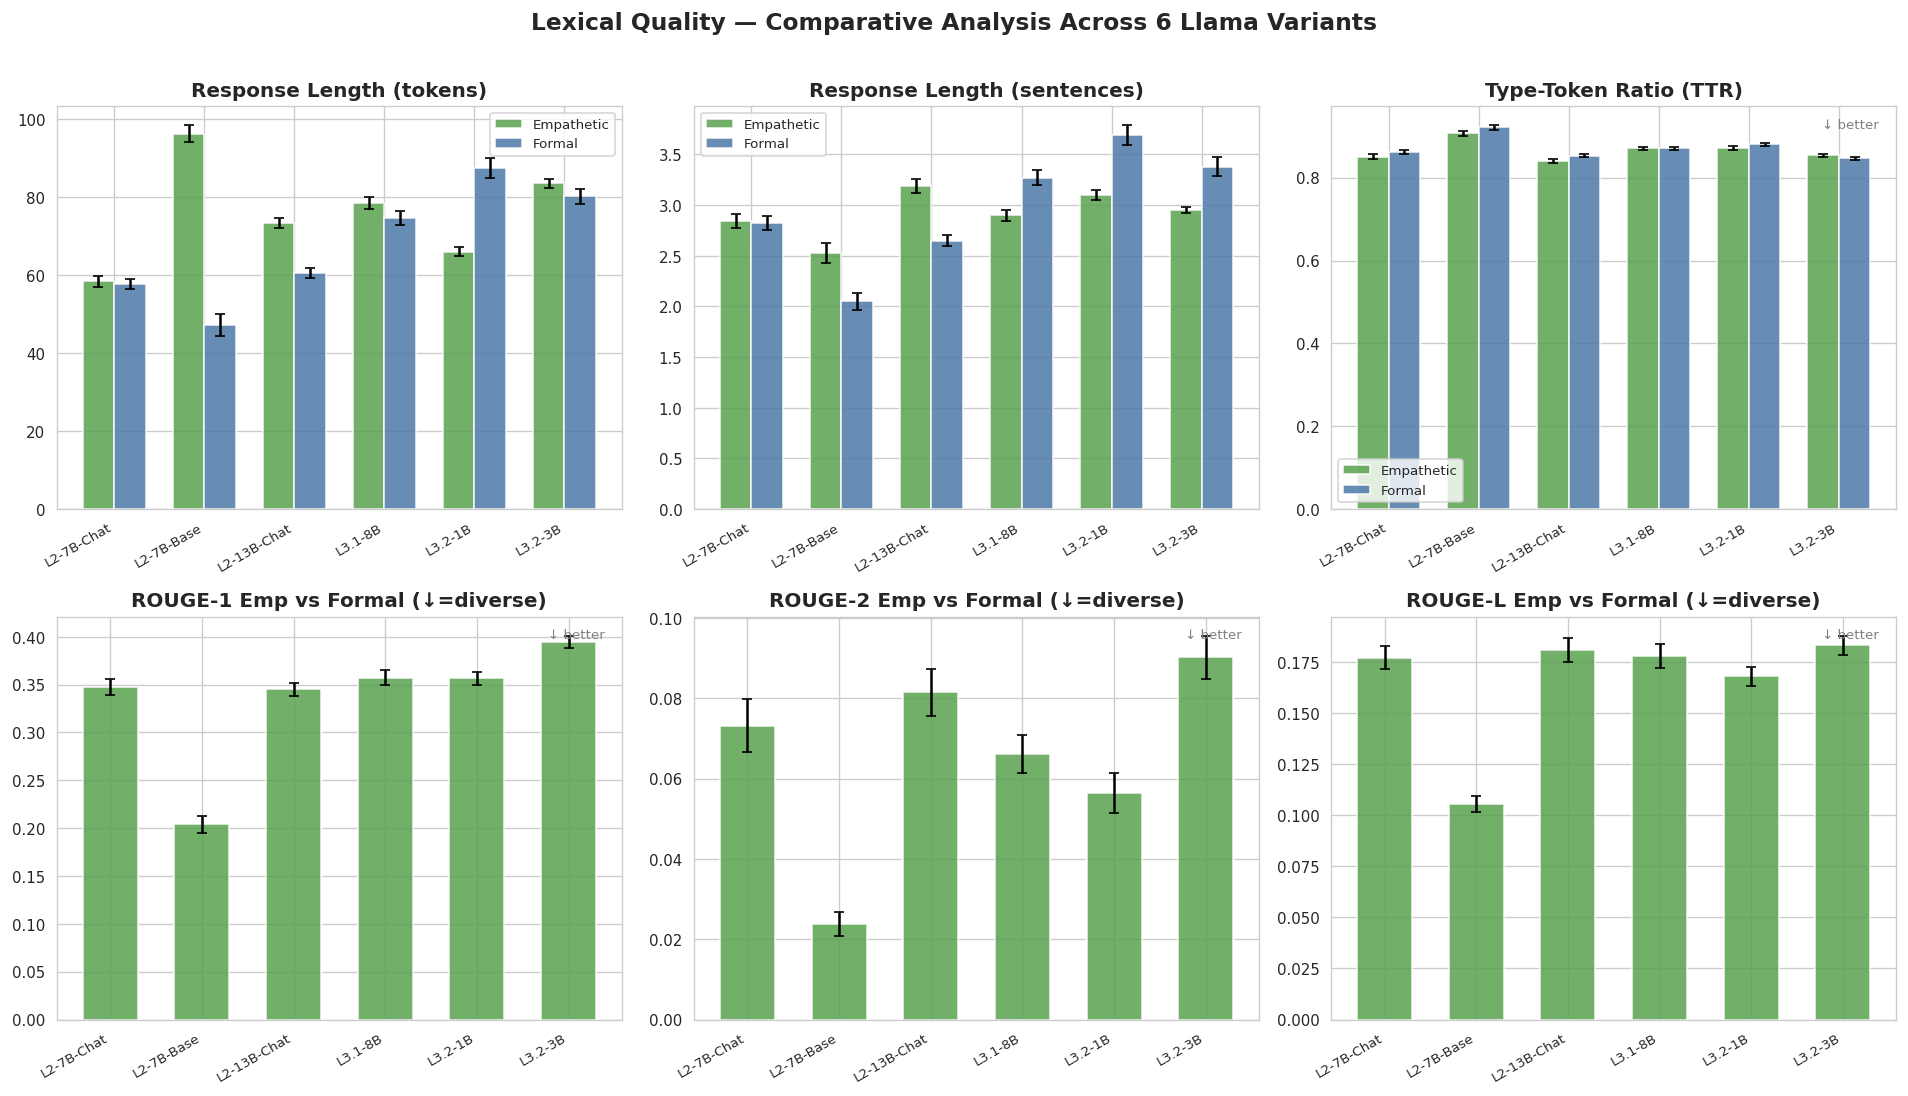

✓ Saved: eval_1_lexical_quality.png


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Lexical Quality — Comparative Analysis Across 6 Llama Variants', fontsize=14, fontweight='bold', y=1.01)

metrics_cfg = [
    ("emp_token_len",  "frm_token_len",  "Response Length (tokens)",        False),
    ("emp_sent_len",   "frm_sent_len",   "Response Length (sentences)",      False),
    ("emp_ttr",        "frm_ttr",        "Type-Token Ratio (TTR)",           True),
    ("rouge1_ef",      None,             "ROUGE-1 Emp vs Formal (↓=diverse)", True),
    ("rouge2_ef",      None,             "ROUGE-2 Emp vs Formal (↓=diverse)", True),
    ("rougeL_ef",      None,             "ROUGE-L Emp vs Formal (↓=diverse)", True),
]

for ax, (emp_col, frm_col, title, lower_better) in zip(axes.flat, metrics_cfg):
    means_emp, means_frm, errs_emp, errs_frm, xlabels = [], [], [], [], []

    for lbl in ORDERED_LABELS:
        df = MODEL_DFS[lbl]
        if emp_col in df.columns:
            means_emp.append(df[emp_col].mean())
            errs_emp.append(df[emp_col].std() / np.sqrt(len(df)))
        else:
            means_emp.append(np.nan); errs_emp.append(0)
        if frm_col and frm_col in df.columns:
            means_frm.append(df[frm_col].mean())
            errs_frm.append(df[frm_col].std() / np.sqrt(len(df)))
        else:
            means_frm.append(None); errs_frm.append(0)
        xlabels.append(SHORT[lbl])

    x = np.arange(len(ORDERED_LABELS))
    w = 0.35 if frm_col else 0.6

    bars_e = ax.bar(x - w/2 if frm_col else x, means_emp,
                    width=w, yerr=errs_emp, capsize=3,
                    color='#59a14f', alpha=0.85, label='Empathetic')
    if frm_col:
        bars_f = ax.bar(x + w/2, means_frm,
                        width=w, yerr=errs_frm, capsize=3,
                        color='#4e79a7', alpha=0.85, label='Formal')

    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, rotation=30, ha='right', fontsize=8)
    if frm_col: ax.legend(fontsize=8)
    if lower_better:
        ax.text(0.97, 0.97, '↓ better', transform=ax.transAxes,
                ha='right', va='top', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('eval_1_lexical_quality.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Saved: eval_1_lexical_quality.png')

---
# Part 2 — Readability Analysis

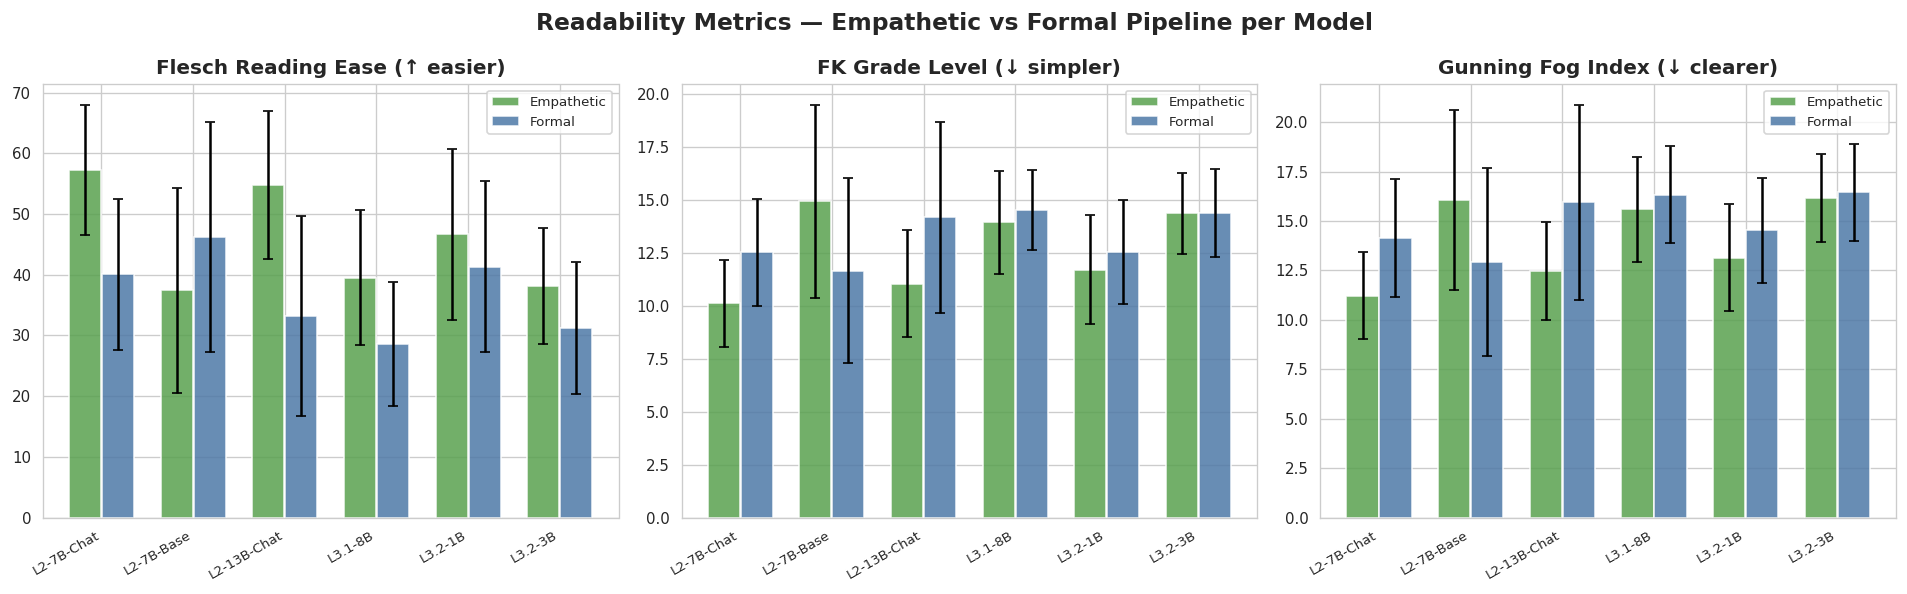

✓ Saved: eval_2_readability.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Readability Metrics — Empathetic vs Formal Pipeline per Model', fontsize=14, fontweight='bold')

read_metrics = [
    ('emp_flesch_ease',  'frm_flesch_ease',  'Flesch Reading Ease (↑ easier)'),
    ('emp_flesch_grade', 'frm_flesch_grade',  'FK Grade Level (↓ simpler)'),
    ('emp_fog',          'frm_fog',           'Gunning Fog Index (↓ clearer)'),
]

for ax, (ec, fc, title) in zip(axes, read_metrics):
    xlabels = [SHORT[l] for l in ORDERED_LABELS]
    x = np.arange(len(ORDERED_LABELS))

    emp_means = [MODEL_DFS[l][ec].mean() if ec in MODEL_DFS[l].columns else np.nan for l in ORDERED_LABELS]
    frm_means = [MODEL_DFS[l][fc].mean() if fc in MODEL_DFS[l].columns else np.nan for l in ORDERED_LABELS]
    emp_std   = [MODEL_DFS[l][ec].std()  if ec in MODEL_DFS[l].columns else 0       for l in ORDERED_LABELS]
    frm_std   = [MODEL_DFS[l][fc].std()  if fc in MODEL_DFS[l].columns else 0       for l in ORDERED_LABELS]

    ax.bar(x - 0.18, emp_means, width=0.35, yerr=emp_std, capsize=3,
           color='#59a14f', alpha=0.85, label='Empathetic')
    ax.bar(x + 0.18, frm_means, width=0.35, yerr=frm_std, capsize=3,
           color='#4e79a7', alpha=0.85, label='Formal')

    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, rotation=30, ha='right', fontsize=8)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('eval_2_readability.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Saved: eval_2_readability.png')

---
# Part 3 — Style Fidelity

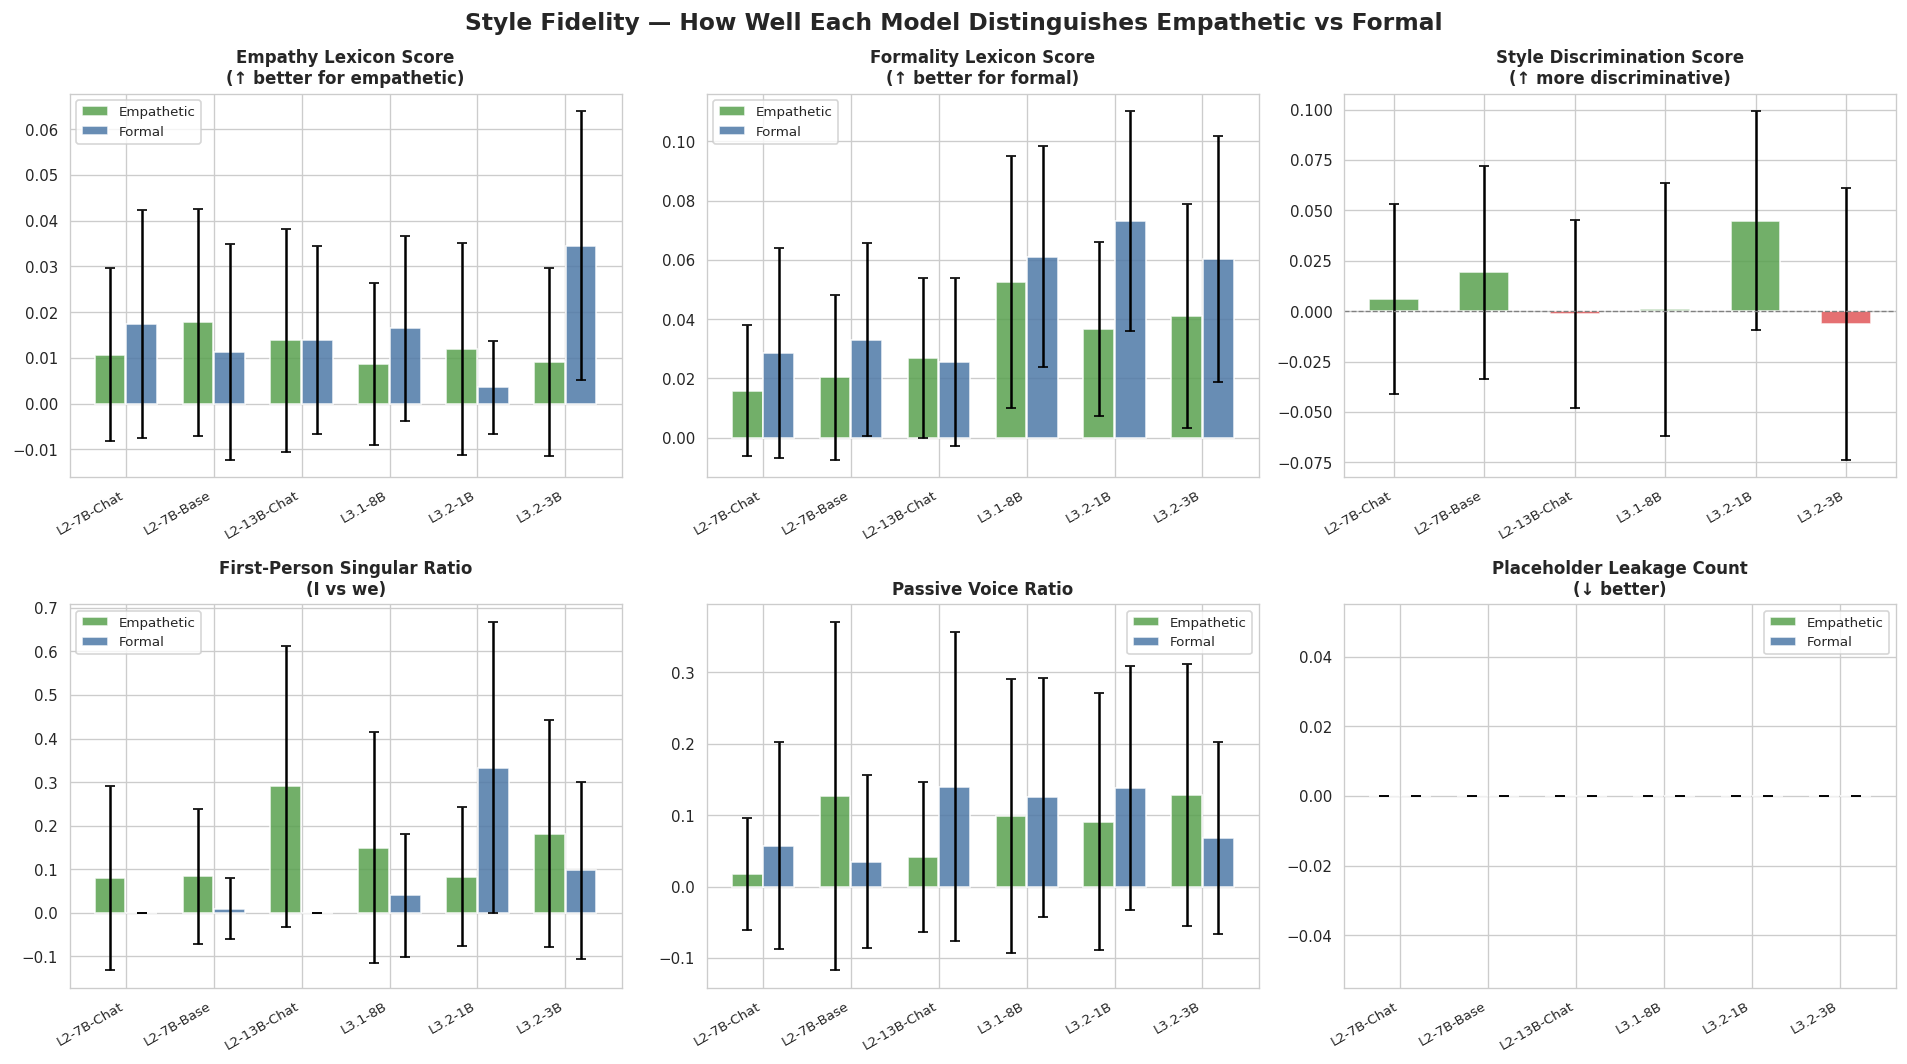

✓ Saved: eval_3_style_fidelity.png


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Style Fidelity — How Well Each Model Distinguishes Empathetic vs Formal', fontsize=14, fontweight='bold')

style_cfgs = [
    ('emp_empathy_score',   'frm_empathy_score',   'Empathy Lexicon Score\n(↑ better for empathetic)'),
    ('emp_formality_score', 'frm_formality_score',  'Formality Lexicon Score\n(↑ better for formal)'),
    ('style_disc_score',    None,                   'Style Discrimination Score\n(↑ more discriminative)'),
    ('emp_fp_singular',     'frm_fp_singular',      'First-Person Singular Ratio\n(I vs we)'),
    ('emp_passive',         'frm_passive',           'Passive Voice Ratio'),
    ('emp_placeholder',     'frm_placeholder',       'Placeholder Leakage Count\n(↓ better)'),
]

for ax, (ec, fc, title) in zip(axes.flat, style_cfgs):
    x = np.arange(len(ORDERED_LABELS))
    xlabels = [SHORT[l] for l in ORDERED_LABELS]

    em = [MODEL_DFS[l][ec].mean() if ec in MODEL_DFS[l].columns else np.nan for l in ORDERED_LABELS]
    es = [MODEL_DFS[l][ec].std()  if ec in MODEL_DFS[l].columns else 0       for l in ORDERED_LABELS]

    if fc:
        fm = [MODEL_DFS[l][fc].mean() if fc in MODEL_DFS[l].columns else np.nan for l in ORDERED_LABELS]
        fs = [MODEL_DFS[l][fc].std()  if fc in MODEL_DFS[l].columns else 0       for l in ORDERED_LABELS]
        ax.bar(x - 0.18, em, width=0.35, yerr=es, capsize=3, color='#59a14f', alpha=0.85, label='Empathetic')
        ax.bar(x + 0.18, fm, width=0.35, yerr=fs, capsize=3, color='#4e79a7', alpha=0.85, label='Formal')
        ax.legend(fontsize=8)
    else:
        colors = ['#59a14f' if v >= 0 else '#e15759' for v in em]
        ax.bar(x, em, width=0.55, yerr=es, capsize=3, color=colors, alpha=0.85)
        ax.axhline(0, color='gray', lw=0.8, ls='--')

    ax.set_title(title, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, rotation=30, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('eval_3_style_fidelity.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Saved: eval_3_style_fidelity.png')

---
# Part 4 — Factual Grounding (KG Entity Coverage)

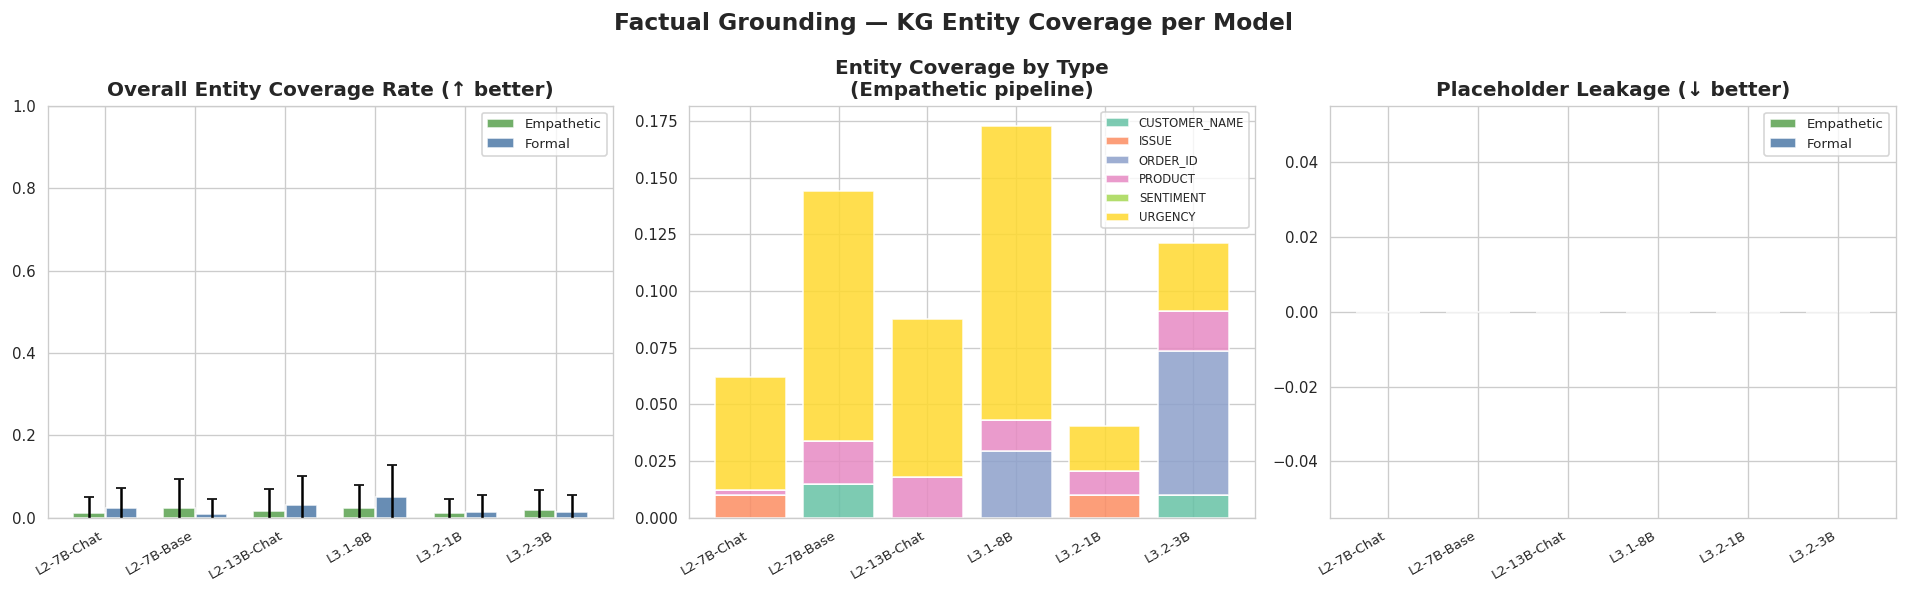

✓ Saved: eval_4_factual_grounding.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Factual Grounding — KG Entity Coverage per Model', fontsize=14, fontweight='bold')

# ── Panel 1: Overall entity coverage ─────────────────────────────────────────
ax = axes[0]
x  = np.arange(len(ORDERED_LABELS))
em = [MODEL_DFS[l]['emp_entity_cov'].mean() if 'emp_entity_cov' in MODEL_DFS[l].columns else np.nan for l in ORDERED_LABELS]
fm = [MODEL_DFS[l]['frm_entity_cov'].mean() if 'frm_entity_cov' in MODEL_DFS[l].columns else np.nan for l in ORDERED_LABELS]
es = [MODEL_DFS[l]['emp_entity_cov'].std()  if 'emp_entity_cov' in MODEL_DFS[l].columns else 0      for l in ORDERED_LABELS]
fs = [MODEL_DFS[l]['frm_entity_cov'].std()  if 'frm_entity_cov' in MODEL_DFS[l].columns else 0      for l in ORDERED_LABELS]
ax.bar(x-0.18, em, 0.35, yerr=es, capsize=3, color='#59a14f', alpha=0.85, label='Empathetic')
ax.bar(x+0.18, fm, 0.35, yerr=fs, capsize=3, color='#4e79a7', alpha=0.85, label='Formal')
ax.set_title('Overall Entity Coverage Rate (↑ better)')
ax.set_xticks(x); ax.set_xticklabels([SHORT[l] for l in ORDERED_LABELS], rotation=30, ha='right', fontsize=8)
ax.set_ylim(0, 1); ax.legend(fontsize=8)

# ── Panel 2: Coverage by entity type (stacked, empathetic pipeline) ───────────
ax = axes[1]
type_cols_e = [c for c in ALL_DF.columns if c.startswith('emp_cov_') and not c.endswith('_cov_')]
# determine all entity types that exist
etype_cols = sorted(set(
    c.replace('emp_cov_','') for c in ALL_DF.columns if c.startswith('emp_cov_')
))
etype_palette = sns.color_palette('Set2', n_colors=max(len(etype_cols),1))
bottom = np.zeros(len(ORDERED_LABELS))
for i, et in enumerate(etype_cols):
    col = f'emp_cov_{et}'
    vals = [MODEL_DFS[l][col].mean() if col in MODEL_DFS[l].columns else 0 for l in ORDERED_LABELS]
    ax.bar(np.arange(len(ORDERED_LABELS)), vals, bottom=bottom,
           color=etype_palette[i], alpha=0.85, label=et.upper())
    bottom += np.array(vals)
ax.set_title('Entity Coverage by Type\n(Empathetic pipeline)')
ax.set_xticks(np.arange(len(ORDERED_LABELS)))
ax.set_xticklabels([SHORT[l] for l in ORDERED_LABELS], rotation=30, ha='right', fontsize=8)
ax.legend(fontsize=7, loc='upper right')

# ── Panel 3: Placeholder leakage ─────────────────────────────────────────────
ax = axes[2]
ep = [MODEL_DFS[l]['emp_placeholder'].mean() if 'emp_placeholder' in MODEL_DFS[l].columns else 0 for l in ORDERED_LABELS]
fp = [MODEL_DFS[l]['frm_placeholder'].mean() if 'frm_placeholder' in MODEL_DFS[l].columns else 0 for l in ORDERED_LABELS]
ax.bar(x-0.18, ep, 0.35, color='#59a14f', alpha=0.85, label='Empathetic')
ax.bar(x+0.18, fp, 0.35, color='#4e79a7', alpha=0.85, label='Formal')
ax.set_title('Placeholder Leakage (↓ better)')
ax.set_xticks(x); ax.set_xticklabels([SHORT[l] for l in ORDERED_LABELS], rotation=30, ha='right', fontsize=8)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('eval_4_factual_grounding.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Saved: eval_4_factual_grounding.png')

---
# Part 5 — KG Structural Quality

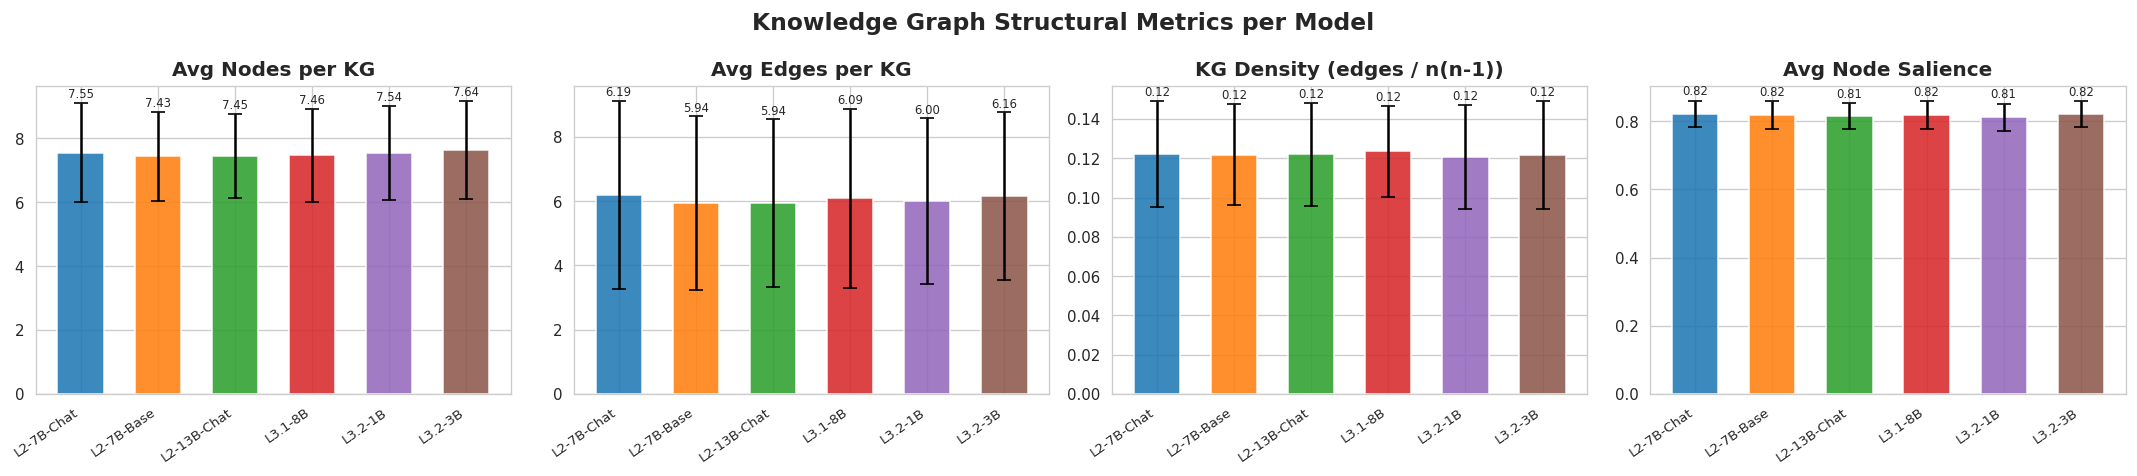

✓ Saved: eval_5_kg_structure.png


In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Knowledge Graph Structural Metrics per Model', fontsize=14, fontweight='bold')

kg_metrics = [
    ('kg_nodes',   'Avg Nodes per KG'),
    ('kg_edges',   'Avg Edges per KG'),
    ('kg_density', 'KG Density (edges / n(n-1))'),
    ('kg_salience','Avg Node Salience'),
]

for ax, (col, title) in zip(axes, kg_metrics):
    means = [MODEL_DFS[l][col].mean() if col in MODEL_DFS[l].columns else 0 for l in ORDERED_LABELS]
    stds  = [MODEL_DFS[l][col].std()  if col in MODEL_DFS[l].columns else 0 for l in ORDERED_LABELS]
    colors = [MODEL_COLOR[l] for l in ORDERED_LABELS]
    x = np.arange(len(ORDERED_LABELS))
    ax.bar(x, means, width=0.6, yerr=stds, capsize=4, color=colors, alpha=0.87)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels([SHORT[l] for l in ORDERED_LABELS], rotation=35, ha='right', fontsize=8)

    # Annotate values on top
    for i, (m, s) in enumerate(zip(means, stds)):
        ax.text(i, m + s + max(means)*0.01, f'{m:.2f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('eval_5_kg_structure.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Saved: eval_5_kg_structure.png')

---
# Part 6 — Radar / Spider Chart — Overall Model Profiles

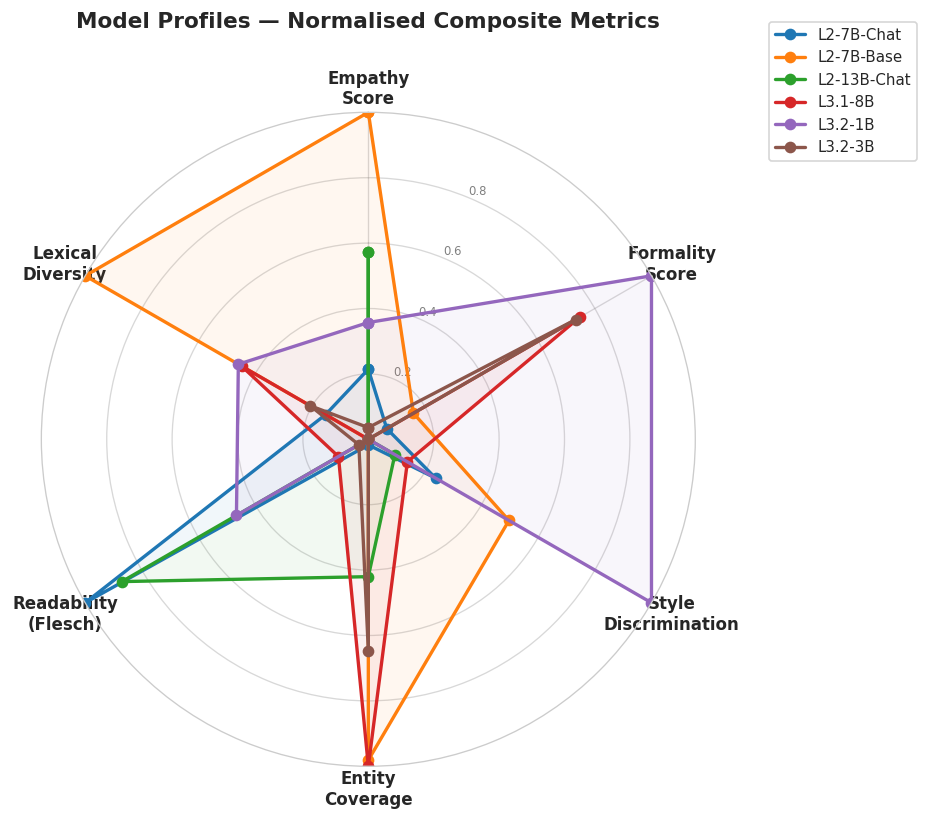

✓ Saved: eval_6_radar.png


In [12]:
import matplotlib.ticker as ticker

# Composite metric definitions: (metric_col, friendly_name, higher_is_better)
RADAR_METRICS = [
    ('emp_empathy_score',  'Empathy\nScore',         True),
    ('frm_formality_score','Formality\nScore',        True),
    ('style_disc_score',   'Style\nDiscrimination',   True),
    ('emp_entity_cov',     'Entity\nCoverage',        True),
    ('emp_flesch_ease',    'Readability\n(Flesch)',    True),
    ('emp_ttr',            'Lexical\nDiversity',      True),
]

def _normalize_radar(model_scores: dict) -> dict:
    """Min-max normalize each axis across models to [0,1]."""
    result = {}
    for col, _, higher_better in RADAR_METRICS:
        vals = {m: model_scores[m].get(col, 0) for m in model_scores}
        mn, mx = min(vals.values()), max(vals.values())
        rng = mx - mn if mx != mn else 1
        for m in vals:
            v = (vals[m] - mn) / rng
            if not higher_better: v = 1 - v
            result.setdefault(m, {})[col] = v
    return result

# Gather mean per model
raw_scores = {}
for lbl in ORDERED_LABELS:
    df = MODEL_DFS[lbl]
    raw_scores[lbl] = {col: df[col].mean() if col in df.columns else 0 for col, _, _ in RADAR_METRICS}

norm_scores = _normalize_radar(raw_scores)
labels_radar = [name for _, name, _ in RADAR_METRICS]
N = len(labels_radar)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=10, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(['0.2','0.4','0.6','0.8'], fontsize=7, color='gray')
ax.grid(color='gray', alpha=0.3)

for lbl in ORDERED_LABELS:
    vals = [norm_scores[lbl][col] for col, _, _ in RADAR_METRICS]
    vals += vals[:1]
    ax.plot(angles, vals, '-o', lw=2, color=MODEL_COLOR[lbl], label=SHORT[lbl])
    ax.fill(angles, vals, alpha=0.06, color=MODEL_COLOR[lbl])

ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax.set_title('Model Profiles — Normalised Composite Metrics', fontsize=13, fontweight='bold', pad=25)

plt.tight_layout()
plt.savefig('eval_6_radar.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Saved: eval_6_radar.png')

---
# Part 7 — Cross-Scenario & Cross-Sentiment Analysis

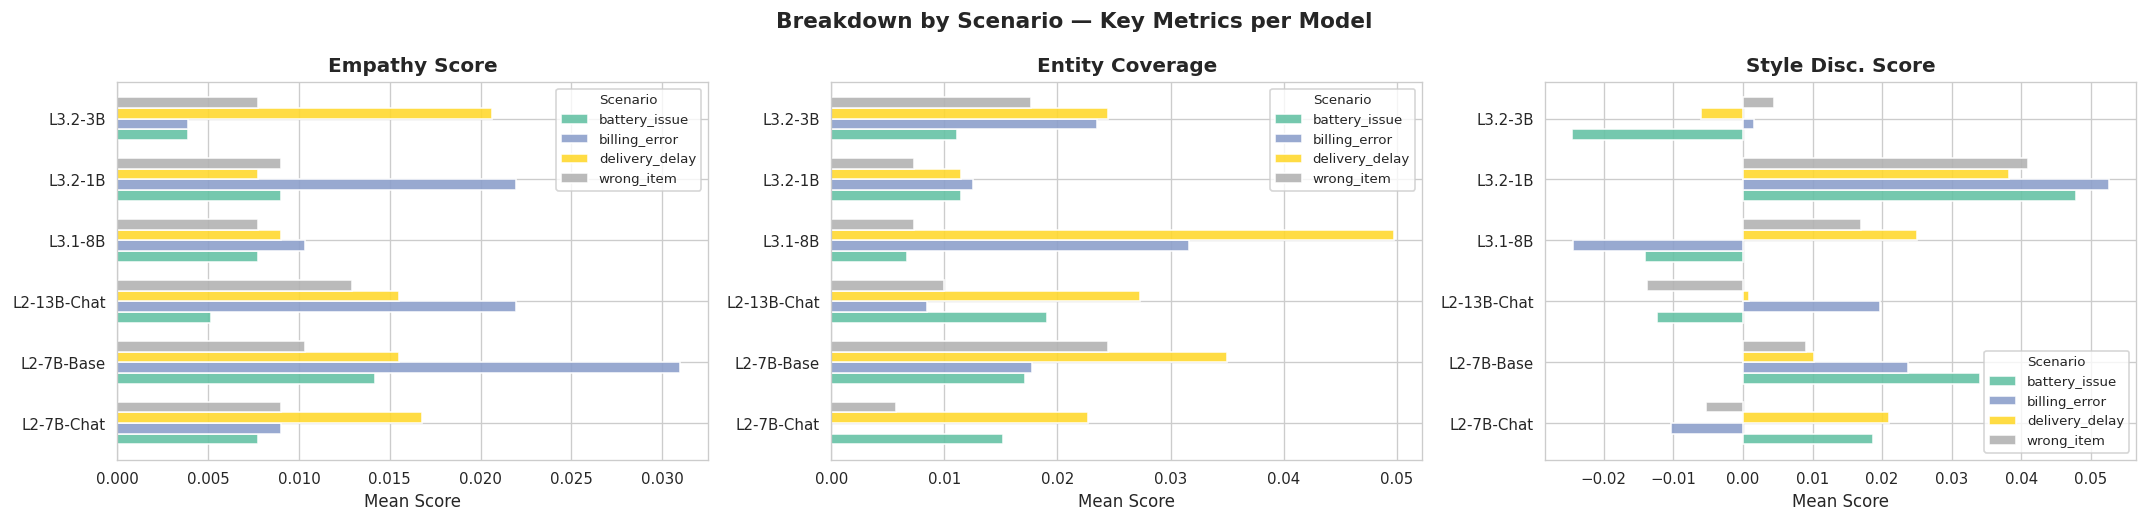

✓ Saved: eval_7a_scenario_breakdown.png


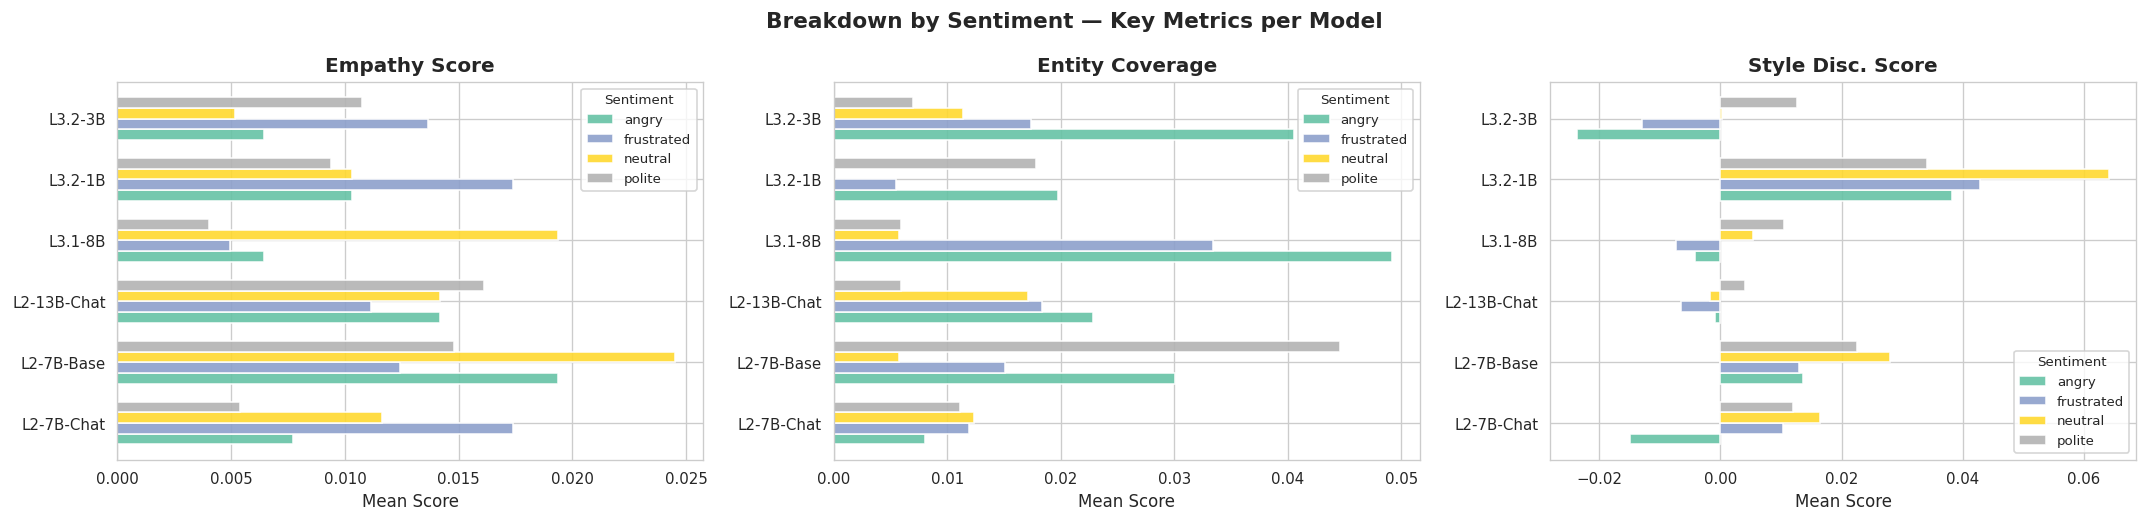

✓ Saved: eval_7b_sentiment_breakdown.png


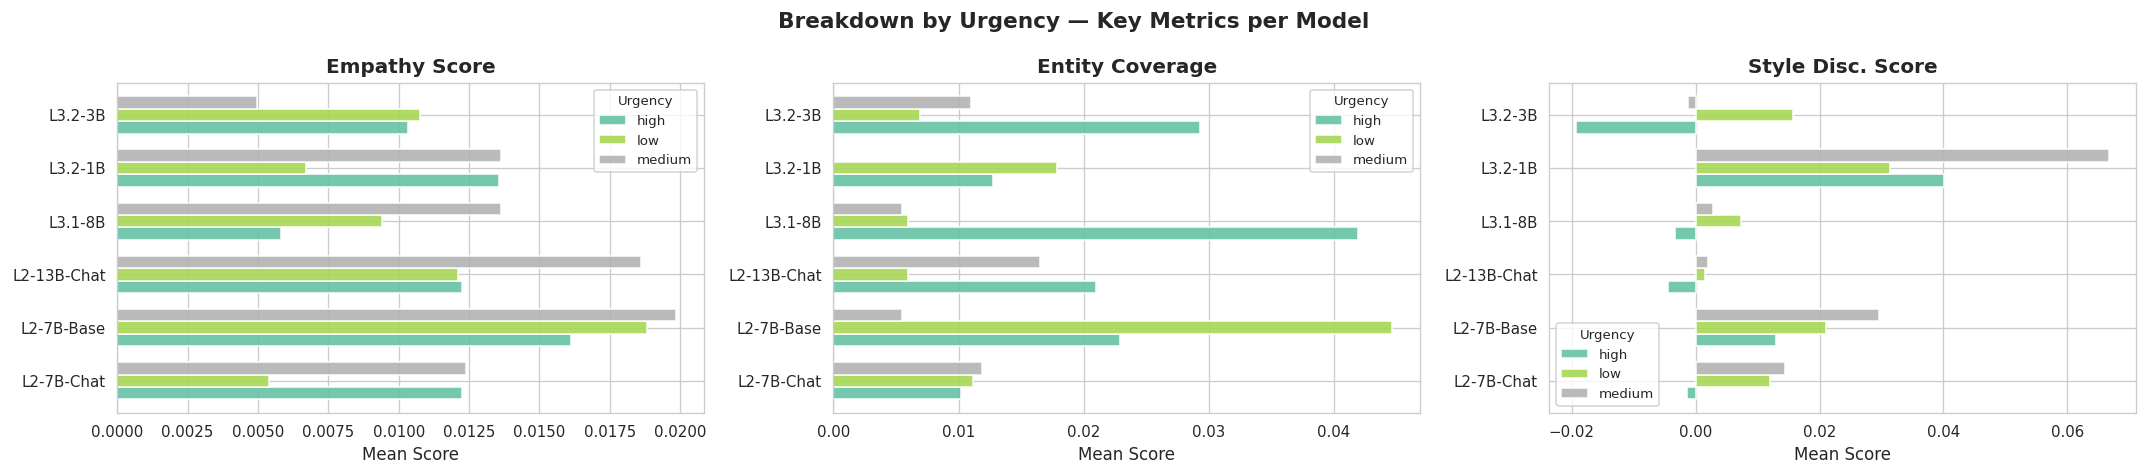

✓ Saved: eval_7c_urgency_breakdown.png


In [13]:
# ── Select the 3 most informative metrics for breakdown ───────────────────────
breakdown_metrics = [
    ('emp_empathy_score',  'Empathy Score'),
    ('emp_entity_cov',     'Entity Coverage'),
    ('style_disc_score',   'Style Disc. Score'),
]

def plot_breakdown(group_col, group_name, fig_name):
    # Collect all group values across all models
    all_groups = sorted(ALL_DF[group_col].dropna().unique()) if group_col in ALL_DF.columns else []
    if not all_groups:
        print(f'  ✗ No data for {group_col}')
        return

    n_metrics = len(breakdown_metrics)
    n_groups  = len(all_groups)
    fig, axes = plt.subplots(1, n_metrics, figsize=(6*n_metrics, max(4, n_groups*1.1)))
    fig.suptitle(f'Breakdown by {group_name} — Key Metrics per Model', fontsize=13, fontweight='bold')

    for ax, (col, label) in zip(axes if n_metrics > 1 else [axes], breakdown_metrics):
        if col not in ALL_DF.columns:
            ax.set_title(f'{label}\n(not available)')
            continue

        grp_df = ALL_DF.groupby(['model_short', group_col])[col].mean().unstack(group_col)
        grp_df = grp_df.reindex([SHORT[l] for l in ORDERED_LABELS if SHORT[l] in grp_df.index])
        grp_df.plot(kind='barh', ax=ax, colormap='Set2', alpha=0.9, width=0.7)
        ax.set_title(label)
        ax.set_xlabel('Mean Score')
        ax.set_ylabel('')
        ax.legend(title=group_name, fontsize=8, title_fontsize=8)

    plt.tight_layout()
    plt.savefig(fig_name, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'✓ Saved: {fig_name}')

plot_breakdown('scenario',  'Scenario',  'eval_7a_scenario_breakdown.png')
plot_breakdown('sentiment', 'Sentiment', 'eval_7b_sentiment_breakdown.png')
plot_breakdown('urgency',   'Urgency',   'eval_7c_urgency_breakdown.png')

---
# Part 8 — Steering Mode Distribution

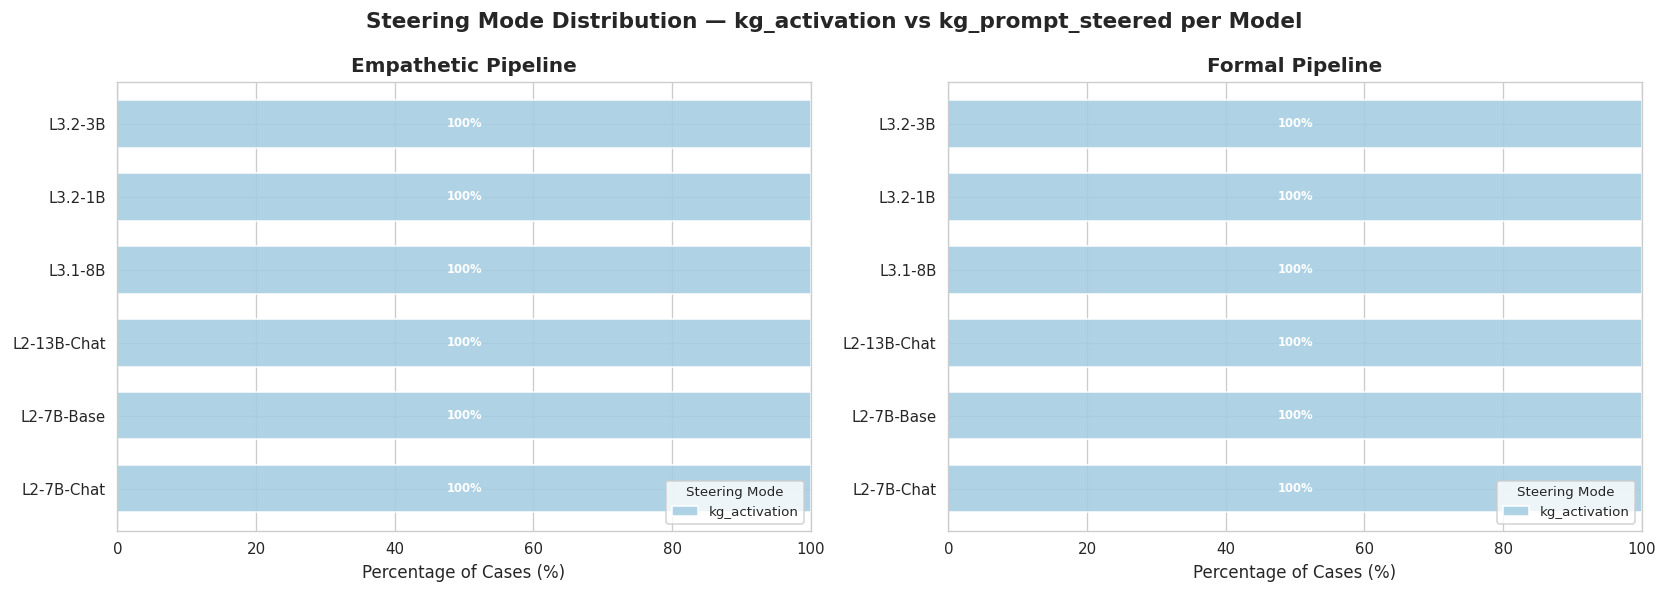

✓ Saved: eval_8_steering_mode.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Steering Mode Distribution — kg_activation vs kg_prompt_steered per Model', fontsize=13, fontweight='bold')

for ax, (col, title) in zip(axes, [('emp_steering','Empathetic Pipeline'), ('frm_steering','Formal Pipeline')]):
    if col not in ALL_DF.columns:
        ax.set_title(f'{title} (no data)'); continue

    pivot = ALL_DF.groupby(['model_short', col]).size().unstack(col).fillna(0)
    pivot = pivot.reindex([SHORT[l] for l in ORDERED_LABELS if SHORT[l] in pivot.index])
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

    pivot_pct.plot(kind='barh', stacked=True, ax=ax,
                   color=sns.color_palette('Paired', n_colors=max(len(pivot_pct.columns),2)),
                   alpha=0.9, width=0.65)
    ax.set_title(title)
    ax.set_xlabel('Percentage of Cases (%)')
    ax.set_ylabel('')
    ax.set_xlim(0, 100)
    ax.legend(title='Steering Mode', fontsize=8, title_fontsize=8, loc='lower right')
    for bar_container in ax.containers:
        ax.bar_label(bar_container, fmt='%.0f%%', label_type='center', fontsize=7, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('eval_8_steering_mode.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Saved: eval_8_steering_mode.png')

---
# Part 9 — Statistical Tests (Welch's t-test + Cohen's d)

In [15]:
STAT_PAIRS = [
    ('emp_token_len',       'frm_token_len',       'Response Length'),
    ('emp_ttr',             'frm_ttr',             'Type-Token Ratio'),
    ('emp_flesch_ease',     'frm_flesch_ease',     'Flesch Ease'),
    ('emp_flesch_grade',    'frm_flesch_grade',    'FK Grade'),
    ('emp_fog',             'frm_fog',             'Gunning Fog'),
    ('emp_empathy_score',   'frm_empathy_score',   'Empathy Score'),
    ('emp_formality_score', 'frm_formality_score', 'Formality Score'),
    ('emp_fp_singular',     'frm_fp_singular',     'FP Singular'),
    ('emp_passive',         'frm_passive',         'Passive Ratio'),
    ('emp_entity_cov',      'frm_entity_cov',      'Entity Coverage'),
]

def run_stat_tests(df):
    rows = []
    n_tests = len(STAT_PAIRS)
    for ec, fc, lbl in STAT_PAIRS:
        if ec not in df.columns or fc not in df.columns: continue
        a, b = df[ec].dropna().values, df[fc].dropna().values
        if len(a) < 3 or len(b) < 3: continue
        t, p = stats.ttest_ind(a, b, equal_var=False)
        p_bonf = min(p * n_tests, 1.0)
        # Cohen's d
        pooled = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
        d = (np.mean(a) - np.mean(b)) / pooled if pooled else 0.0
        rows.append({'Metric': lbl, 'Emp Mean': np.mean(a), 'Frm Mean': np.mean(b),
                     't-stat': t, 'p-value': p, 'p (Bonf.)': p_bonf,
                     "Cohen's d": d, 'Sig.*': '✓' if p_bonf < 0.05 else ''})
    return pd.DataFrame(rows)

# Run for each model
all_stat = {}
for lbl in ORDERED_LABELS:
    all_stat[lbl] = run_stat_tests(MODEL_DFS[lbl])

# ── Display per-model stat table ──────────────────────────────────────────────
from IPython.display import display
import ipywidgets as widgets

for lbl in ORDERED_LABELS:
    print(f'\n═══ {SHORT[lbl]} — Statistical Tests (Empathetic vs Formal) ═══')
    st = all_stat[lbl].copy()
    for c in ['Emp Mean','Frm Mean',"Cohen's d",'t-stat']:
        if c in st.columns: st[c] = st[c].map(lambda x: f'{x:.4f}')
    for c in ['p-value','p (Bonf.)']:
        if c in st.columns: st[c] = st[c].map(lambda x: f'{x:.4f}')
    display(st.set_index('Metric'))


═══ L2-7B-Chat — Statistical Tests (Empathetic vs Formal) ═══


,Emp Mean,Frm Mean,t-stat,p-value,p (Bonf.),Cohen's d,Sig.*
Metric,,,,,,,
Response Length,58.4500,57.6400,0.4180,0.6764,1.0000,0.0591,
Type-Token Ratio,0.8509,0.8616,-1.4968,0.1360,1.0000,-0.2117,
Flesch Ease,57.3092,40.0335,10.5139,0.0000,0.0000,1.4869,✓
FK Grade,10.1175,12.5349,-7.4410,0.0000,0.0000,-1.0523,✓
Gunning Fog,11.2119,14.1370,-7.8787,0.0000,0.0000,-1.1142,✓
Empathy Score,0.0106,0.0174,-2.1673,0.0315,0.3149,-0.3065,
Formality Score,0.0159,0.0286,-3.0578,0.0026,0.0260,-0.4324,✓
FP Singular,0.0800,0.0000,3.7880,0.0003,0.0026,0.5357,✓
Passive Ratio,0.0175,0.0575,-2.4247,0.0165,0.1649,-0.3429,



═══ L2-7B-Base — Statistical Tests (Empathetic vs Formal) ═══


,Emp Mean,Frm Mean,t-stat,p-value,p (Bonf.),Cohen's d,Sig.*
Metric,,,,,,,
Response Length,96.3100,47.1900,13.7003,0.0000,0.0000,1.9375,✓
Type-Token Ratio,0.9077,0.9214,-1.6852,0.0936,0.9355,-0.2383,
Flesch Ease,37.3958,46.2606,-3.4962,0.0006,0.0058,-0.4944,✓
FK Grade,14.9513,11.6713,5.1933,0.0000,0.0000,0.7344,✓
Gunning Fog,16.0854,12.9251,4.8045,0.0000,0.0000,0.6795,✓
Empathy Score,0.0177,0.0113,1.8846,0.0610,0.6096,0.2665,
Formality Score,0.0203,0.0331,-2.9858,0.0032,0.0319,-0.4223,✓
FP Singular,0.0842,0.0100,4.3651,0.0000,0.0002,0.6173,✓
Passive Ratio,0.1270,0.0350,3.3773,0.0009,0.0094,0.4776,✓



═══ L2-13B-Chat — Statistical Tests (Empathetic vs Formal) ═══


...

,Emp Mean,Frm Mean,t-stat,p-value,p (Bonf.),Cohen's d,Sig.*
Metric,,,,,,,
Response Length,78.4600,74.5600,1.6287,0.1050,1.0000,0.2303,
Type-Token Ratio,0.8707,0.8712,-0.0962,0.9234,1.0000,-0.0136,
Flesch Ease,39.4965,28.6060,7.2070,0.0000,0.0000,1.0192,✓
FK Grade,13.9474,14.5497,-1.9560,0.0520,0.5195,-0.2766,
Gunning Fog,15.6041,16.3281,-1.9968,0.0472,0.4722,-0.2824,
Empathy Score,0.0087,0.0165,-2.8810,0.0044,0.0441,-0.4074,✓
Formality Score,0.0524,0.0610,-1.5232,0.1293,1.0000,-0.2154,
FP Singular,0.1500,0.0401,3.6455,0.0004,0.0037,0.5156,✓
Passive Ratio,0.0995,0.1250,-1.0019,0.3176,1.0000,-0.1417,



═══ L3.2-1B — Statistical Tests (Empathetic vs Formal) ═══


,Emp Mean,Frm Mean,t-stat,p-value,p (Bonf.),Cohen's d,Sig.*
Metric,,,,,,,
Response Length,66.0300,87.5700,-7.5875,0.0000,0.0000,-1.0730,✓
Type-Token Ratio,0.8715,0.8804,-1.7357,0.0843,0.8425,-0.2455,
Flesch Ease,46.6692,41.3372,2.6809,0.0080,0.0796,0.3791,
FK Grade,11.7201,12.5628,-2.3571,0.0194,0.1940,-0.3333,
Gunning Fog,13.1475,14.5232,-3.6215,0.0004,0.0037,-0.5122,✓
Empathy Score,0.0119,0.0035,3.3096,0.0012,0.0120,0.4680,✓
Formality Score,0.0366,0.0731,-7.7292,0.0000,0.0000,-1.0931,✓
FP Singular,0.0832,0.3333,-6.7539,0.0000,0.0000,-0.9551,✓
Passive Ratio,0.0908,0.1380,-1.9031,0.0585,0.5848,-0.2691,



═══ L3.2-3B — Statistical Tests (Empathetic vs Formal) ═══


,Emp Mean,Frm Mean,t-stat,p-value,p (Bonf.),Cohen's d,Sig.*
Metric,,,,,,,
Response Length,83.5300,80.2100,1.4978,0.1361,1.0000,0.2118,
Type-Token Ratio,0.8545,0.8469,1.5124,0.1320,1.0000,0.2139,
Flesch Ease,38.0607,31.1826,4.7447,0.0000,0.0000,0.6710,✓
FK Grade,14.3921,14.4141,-0.0777,0.9381,1.0000,-0.0110,
Gunning Fog,16.1608,16.4546,-0.8906,0.3743,1.0000,-0.1259,
Empathy Score,0.0090,0.0345,-7.0970,0.0000,0.0000,-1.0037,✓
Formality Score,0.0410,0.0603,-3.4414,0.0007,0.0071,-0.4867,✓
FP Singular,0.1818,0.0980,2.5414,0.0119,0.1185,0.3594,
Passive Ratio,0.1283,0.0678,2.6602,0.0085,0.0851,0.3762,


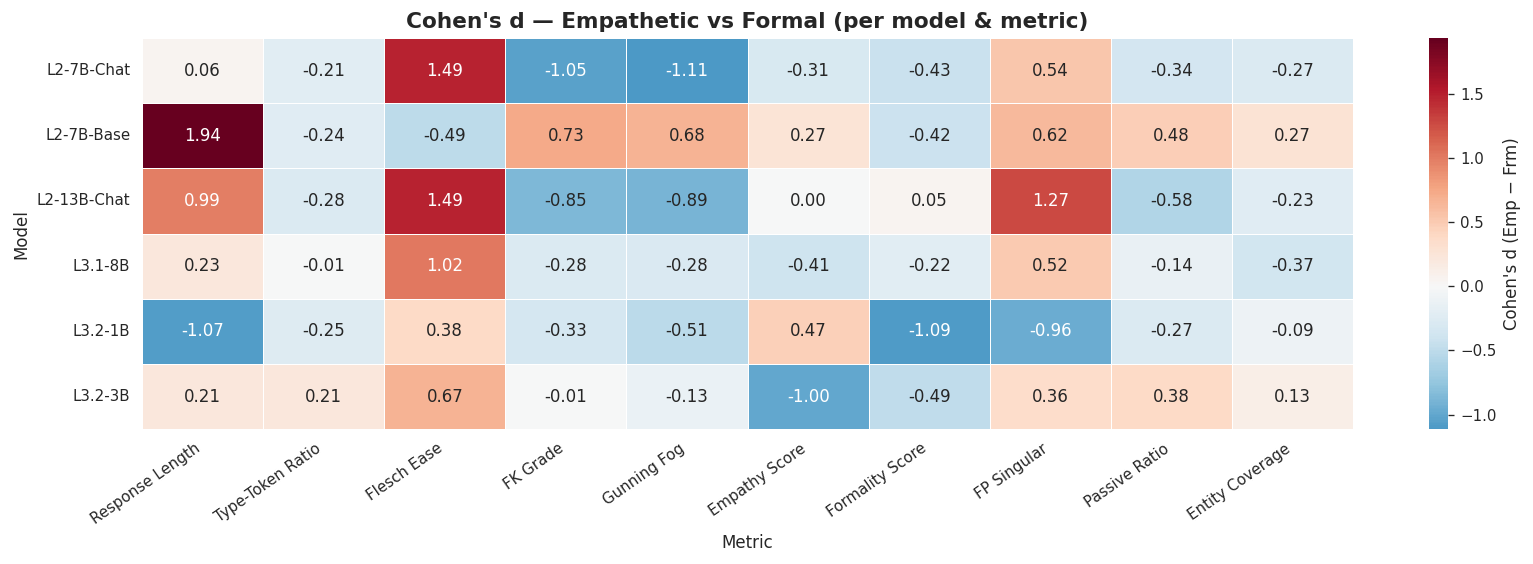

✓ Saved: eval_9_cohens_d_heatmap.png


In [16]:
# ── Cohen's d heatmap across all models ──────────────────────────────────────
cd_rows = {}
for lbl in ORDERED_LABELS:
    st = all_stat[lbl]
    if not st.empty:
        cd_rows[SHORT[lbl]] = st.set_index('Metric')["Cohen's d"].astype(float)

cd_df = pd.DataFrame(cd_rows).T  # models × metrics

if not cd_df.empty:
    fig, ax = plt.subplots(figsize=(14, max(3, len(cd_df)*0.8)))
    sns.heatmap(cd_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                linewidths=0.5, linecolor='white', ax=ax,
                cbar_kws={'label': "Cohen's d (Emp − Frm)"})
    ax.set_title("Cohen's d — Empathetic vs Formal (per model & metric)", fontsize=13, fontweight='bold')
    ax.set_xlabel('Metric')
    ax.set_ylabel('Model')
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.savefig('eval_9_cohens_d_heatmap.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('✓ Saved: eval_9_cohens_d_heatmap.png')

---
# Part 10 — Ablation Study

## Ablation A — Model Size Effect (parameters ↑ → quality ↑?)

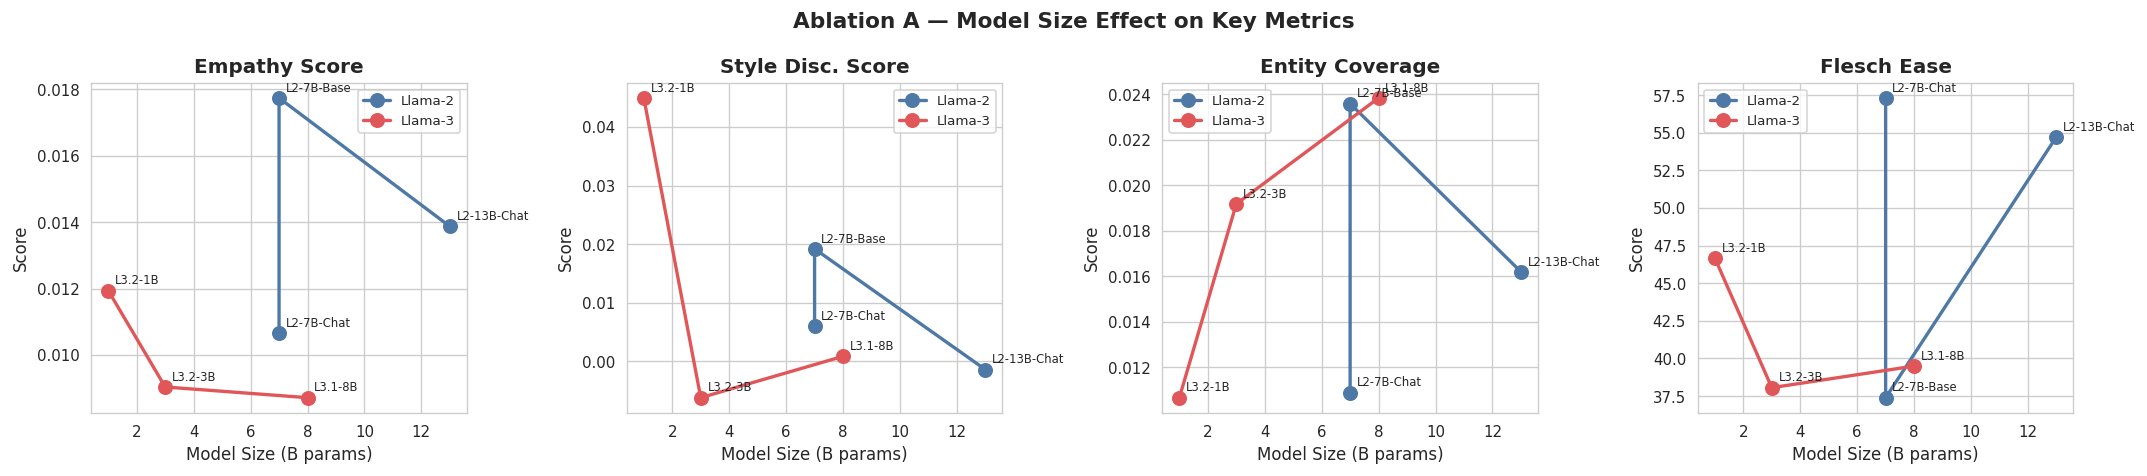

✓ Saved: eval_10a_ablation_size.png


In [17]:
# Build summary DataFrame for ablation
abl_rows = []
for lbl in ORDERED_LABELS:
    df = MODEL_DFS[lbl]
    meta = MODEL_META[lbl]
    row = {
        'model':     SHORT[lbl],
        'generation': meta['generation'],
        'size_B':    meta['size_B'],
        'type':      meta['model_type'],
    }
    for col in ['emp_empathy_score','frm_formality_score','style_disc_score',
                'emp_entity_cov','frm_entity_cov','emp_flesch_ease',
                'emp_ttr','frm_ttr','rouge1_ef','kg_nodes','kg_density',
                'emp_token_len','frm_token_len']:
        row[col] = df[col].mean() if col in df.columns else np.nan
    abl_rows.append(row)

ABL = pd.DataFrame(abl_rows)

# ── Plot: size vs key metrics ─────────────────────────────────────────────────
abl_plot_metrics = [
    ('emp_empathy_score',  'Empathy Score'),
    ('style_disc_score',   'Style Disc. Score'),
    ('emp_entity_cov',     'Entity Coverage'),
    ('emp_flesch_ease',    'Flesch Ease'),
]
fig, axes = plt.subplots(1, len(abl_plot_metrics), figsize=(18, 4))
fig.suptitle('Ablation A — Model Size Effect on Key Metrics', fontsize=13, fontweight='bold')

for ax, (col, lbl) in zip(axes, abl_plot_metrics):
    sub = ABL.dropna(subset=[col])
    for gen, grp in sub.groupby('generation'):
        grp_sorted = grp.sort_values('size_B')
        ax.plot(grp_sorted['size_B'], grp_sorted[col], '-o',
                color=GEN_COLOR.get(gen,'gray'), label=gen, lw=2, ms=8)
        for _, r in grp_sorted.iterrows():
            ax.annotate(r['model'], (r['size_B'], r[col]),
                        textcoords='offset points', xytext=(4,4), fontsize=7)

    ax.set_title(lbl)
    ax.set_xlabel('Model Size (B params)')
    ax.set_ylabel('Score')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('eval_10a_ablation_size.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Saved: eval_10a_ablation_size.png')

## Ablation B — Generation Effect (Llama 2 vs Llama 3.x)

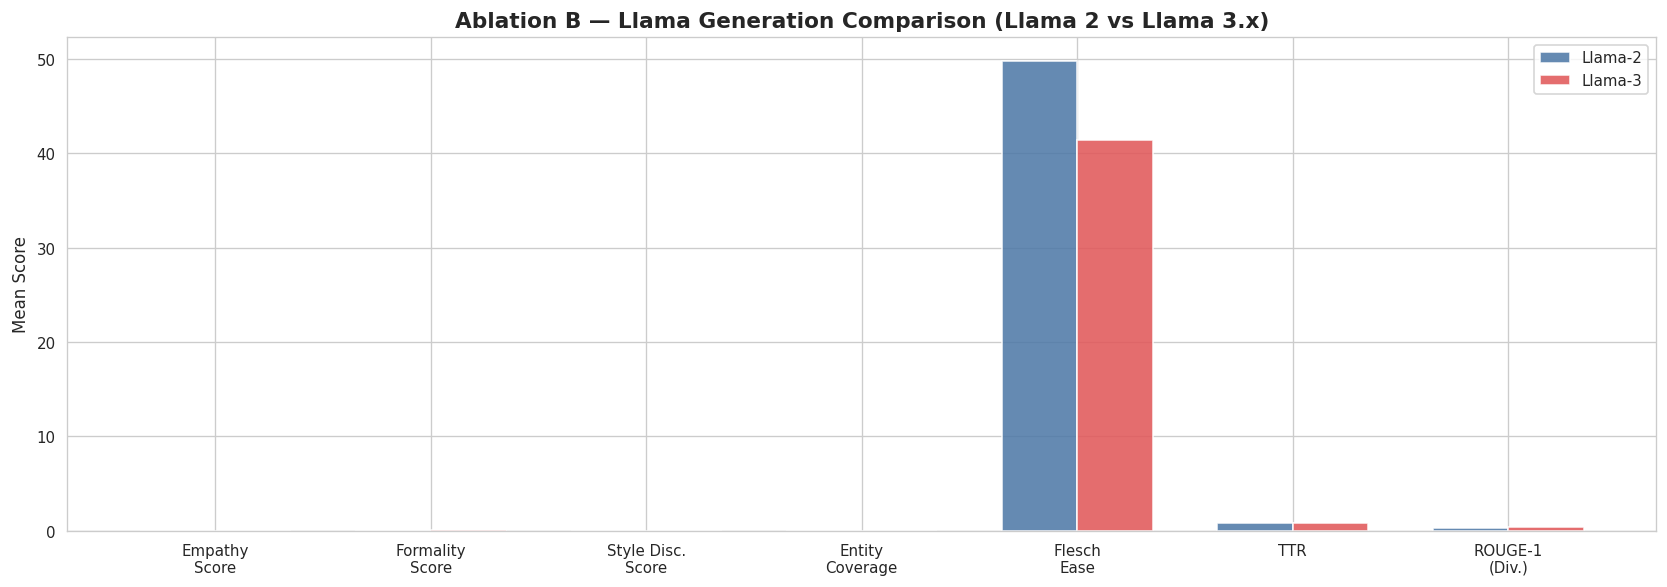

✓ Saved: eval_10b_ablation_generation.png


In [18]:
gen_metrics = [
    'emp_empathy_score','frm_formality_score','style_disc_score',
    'emp_entity_cov','emp_flesch_ease','emp_ttr','rouge1_ef'
]
gen_labels = [
    'Empathy\nScore','Formality\nScore','Style Disc.\nScore',
    'Entity\nCoverage','Flesch\nEase','TTR','ROUGE-1\n(Div.)'
]

gen_grp = ABL.groupby('generation')[gen_metrics].mean()

x = np.arange(len(gen_metrics))
fig, ax = plt.subplots(figsize=(14, 5))

w = 0.35
gens = list(gen_grp.index)
for i, gen in enumerate(gens):
    vals = [gen_grp.loc[gen, m] for m in gen_metrics]
    ax.bar(x + i*w - w*(len(gens)-1)/2, vals, width=w,
           color=GEN_COLOR.get(gen,'gray'), alpha=0.87, label=gen)

ax.set_xticks(x)
ax.set_xticklabels(gen_labels)
ax.set_title('Ablation B — Llama Generation Comparison (Llama 2 vs Llama 3.x)', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Score')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('eval_10b_ablation_generation.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Saved: eval_10b_ablation_generation.png')

## Ablation C — Model Type Effect (Base vs Chat vs Instruct)

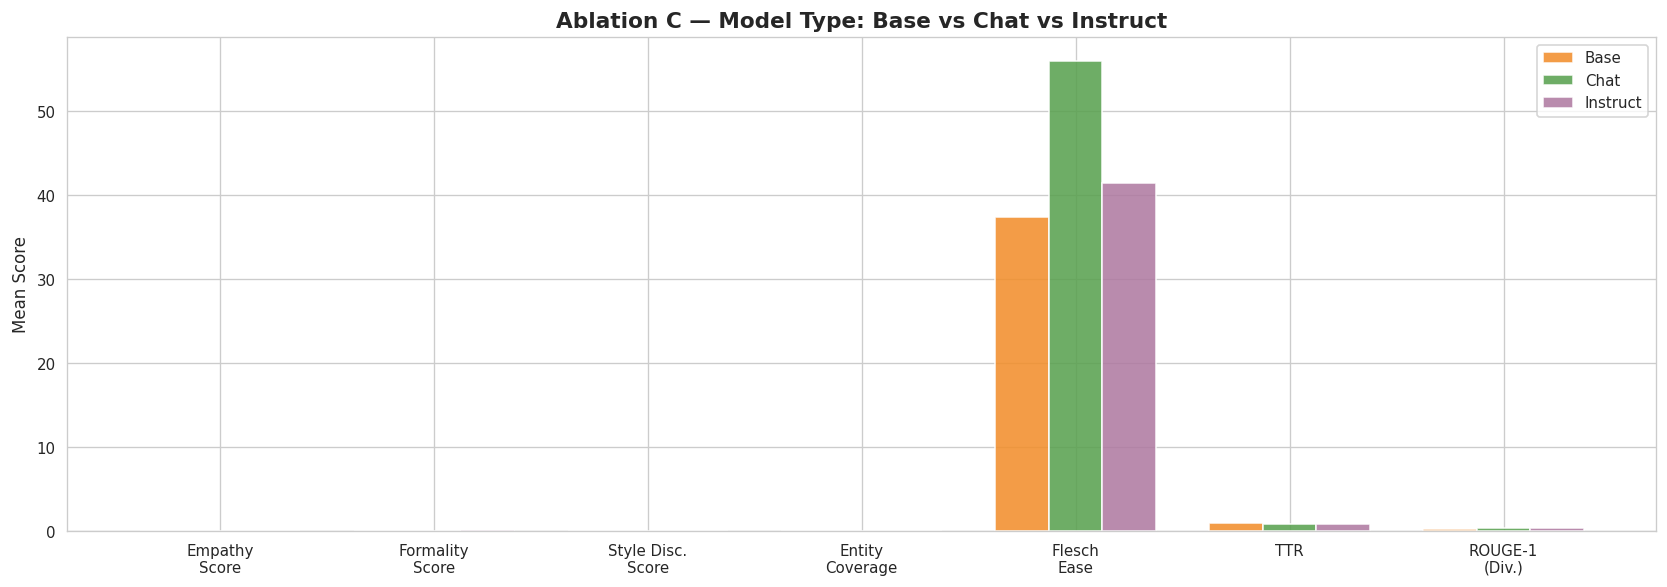

✓ Saved: eval_10c_ablation_type.png


In [19]:
type_grp = ABL.groupby('type')[gen_metrics].mean()

x = np.arange(len(gen_metrics))
fig, ax = plt.subplots(figsize=(14, 5))

types = list(type_grp.index)
for i, t in enumerate(types):
    vals = [type_grp.loc[t, m] for m in gen_metrics]
    ax.bar(x + i*0.25 - 0.25*(len(types)-1)/2, vals, width=0.25,
           color=TYPE_COLOR.get(t,'gray'), alpha=0.87, label=t.capitalize())

ax.set_xticks(x)
ax.set_xticklabels(gen_labels)
ax.set_title('Ablation C — Model Type: Base vs Chat vs Instruct', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Score')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('eval_10c_ablation_type.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Saved: eval_10c_ablation_type.png')

## Ablation D — Activation Steering Success Rate vs Model Size

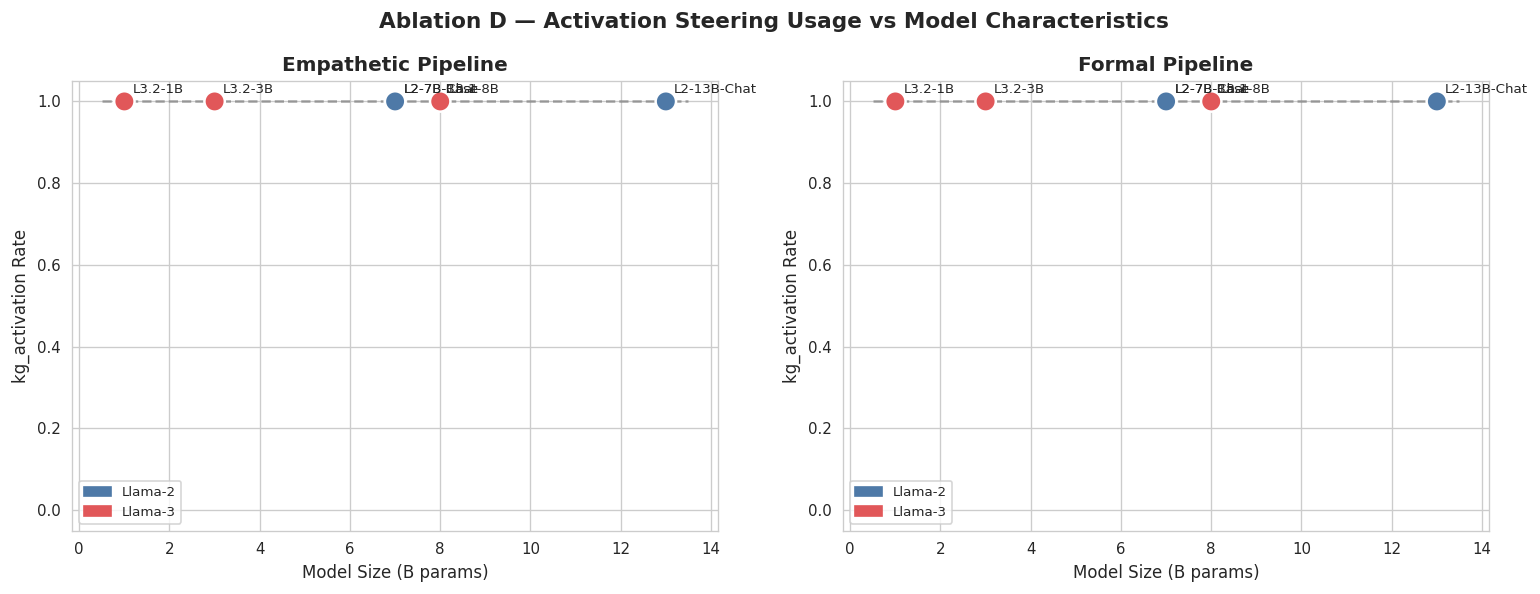

✓ Saved: eval_10d_ablation_steering.png


In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIXED CODE: Ablation D — Activation Steering Usage vs Model Characteristics
# ═══════════════════════════════════════════════════════════════════════════════
# 
# ERROR FIXED:
# - Line 4 was trying to unpack 3 values (pipe, col, title) from tuples with only 2
# - The 'col' variable was never used
# - Solution: Remove 'col' from the unpacking
#
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Ablation D — Activation Steering Usage vs Model Characteristics', fontsize=13, fontweight='bold')

# FIX: Changed (pipe, col, title) to (pipe, title) — col was unused anyway
for ax, (pipe, title) in zip(axes, [
    ('emp_steering', 'Empathetic Pipeline'),
    ('frm_steering', 'Formal Pipeline'),
]):
    # Compute kg_activation rate per model
    rates, sizes, gens, labels_ax = [], [], [], []
    for lbl in ORDERED_LABELS:
        df = MODEL_DFS[lbl]
        if pipe not in df.columns: continue
        total = len(df)
        kg_act = (df[pipe] == 'kg_activation').sum()
        rates.append(kg_act / total if total else 0)
        sizes.append(MODEL_META[lbl]['size_B'])
        gens.append(MODEL_META[lbl]['generation'])
        labels_ax.append(SHORT[lbl])

    scatter = ax.scatter(sizes, rates,
                         c=[list(GEN_COLOR.values())[['Llama-2','Llama-3'].index(g)] for g in gens],
                         s=150, zorder=3, edgecolors='white', linewidth=1.5)

    for s, r, lb in zip(sizes, rates, labels_ax):
        ax.annotate(lb, (s, r), textcoords='offset points', xytext=(5, 5), fontsize=8)

    # Trend line
    if len(sizes) > 1:
        z = np.polyfit(sizes, rates, 1)
        xs = np.linspace(min(sizes)-0.5, max(sizes)+0.5, 100)
        ax.plot(xs, np.poly1d(z)(xs), '--', color='gray', lw=1.5, alpha=0.7, label='Trend')

    ax.set_xlabel('Model Size (B params)')
    ax.set_ylabel('kg_activation Rate')
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(title)

    legend_elems = [mpatches.Patch(color=v, label=k) for k, v in GEN_COLOR.items()]
    ax.legend(handles=legend_elems, fontsize=8)

plt.tight_layout()
plt.savefig('eval_10d_ablation_steering.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Saved: eval_10d_ablation_steering.png')

---
# Part 11 — Summary Leaderboard Table

In [22]:
from IPython.display import HTML

SUMMARY_METRICS = [
    ('emp_empathy_score',   'Empathy Score (Emp)',   True),
    ('frm_formality_score', 'Formality Score (Frm)', True),
    ('style_disc_score',    'Style Disc. Score',     True),
    ('emp_entity_cov',      'Entity Coverage (Emp)', True),
    ('frm_entity_cov',      'Entity Coverage (Frm)', True),
    ('emp_flesch_ease',     'Flesch Ease (Emp)',     True),
    ('emp_ttr',             'TTR (Emp)',             True),
    ('rouge1_ef',           'ROUGE-1 Div.',          False),   # lower = more diverse
    ('kg_nodes',            'KG Nodes',              True),
    ('kg_density',          'KG Density',            True),
    ('emp_placeholder',     'Placeholder Leaks↓',   False),
]

summary_rows = []
for lbl in ORDERED_LABELS:
    df = MODEL_DFS[lbl]
    row = {'Model': SHORT[lbl],
           'Gen': MODEL_META[lbl]['generation'],
           'Size(B)': MODEL_META[lbl]['size_B'],
           'Type': MODEL_META[lbl]['model_type']}
    for col, label, _ in SUMMARY_METRICS:
        row[label] = df[col].mean() if col in df.columns else np.nan
    summary_rows.append(row)

SUM_DF = pd.DataFrame(summary_rows).set_index('Model')

# Compute ranks
rank_rows = {}
for col, label, higher_better in SUMMARY_METRICS:
    vals = SUM_DF[label].dropna()
    ranked = vals.rank(ascending=not higher_better)
    for m in SUM_DF.index:
        rank_rows.setdefault(m, {})[label] = ranked.get(m, np.nan)
RANK_DF = pd.DataFrame(rank_rows).T

# Overall rank (mean rank)
SUM_DF['Overall Rank Score'] = RANK_DF.mean(axis=1)
SUM_DF = SUM_DF.sort_values('Overall Rank Score')

print('\n══ LEADERBOARD (sorted by overall rank score — lower=better) ══')
display(SUM_DF.style
    .format({c: '{:.4f}' for c, *_ in SUMMARY_METRICS if c in SUM_DF.columns})
    .format({'Overall Rank Score': '{:.2f}', 'Size(B)': '{:.0f}'})
    .background_gradient(cmap='YlGn', subset=['Overall Rank Score'], low=0.3)
    .set_caption('A2A KG Pipeline — Model Leaderboard (mean of per-metric ranks)')
)

# Save to CSV
SUM_DF.to_csv('leaderboard_summary.csv')
print('\n✓ Saved: leaderboard_summary.csv')


══ LEADERBOARD (sorted by overall rank score — lower=better) ══


,Gen,Size(B),Type,Empathy Score (Emp),Formality Score (Frm),Style Disc. Score,Entity Coverage (Emp),Entity Coverage (Frm),Flesch Ease (Emp),TTR (Emp),ROUGE-1 Div.,KG Nodes,KG Density,Placeholder Leaks↓,Overall Rank Score
Model,,,,,,,,,,,,,,,
L3.1-8B,Llama-3,8,instruct,0.008710,0.061034,0.000879,0.023838,0.049278,39.496456,0.870690,0.357170,7.460000,0.123598,0.000000,3.14
L2-7B-Chat,Llama-2,7,chat,0.010645,0.028621,0.005984,0.010889,0.022783,57.309219,0.850855,0.347239,7.550000,0.122177,0.000000,3.32
L3.2-1B,Llama-3,1,instruct,0.011935,0.073103,0.044939,0.010664,0.014231,46.669175,0.871468,0.356534,7.540000,0.120730,0.000000,3.32
L2-7B-Base,Llama-2,7,base,0.017742,0.033103,0.019210,0.023592,0.008425,37.395818,0.907666,0.204066,7.430000,0.121860,0.000000,3.41
L2-13B-Chat,Llama-2,13,chat,0.013871,0.025517,-0.001379,0.016198,0.030659,54.729296,0.840753,0.345146,7.450000,0.122065,0.000000,3.68
L3.2-3B,Llama-3,3,instruct,0.009032,0.060345,-0.006174,0.019179,0.013195,38.060732,0.854497,0.394491,7.640000,0.121882,0.000000,4.14



✓ Saved: leaderboard_summary.csv


---
# Part 12 — Distribution Plots (Violin + Box)

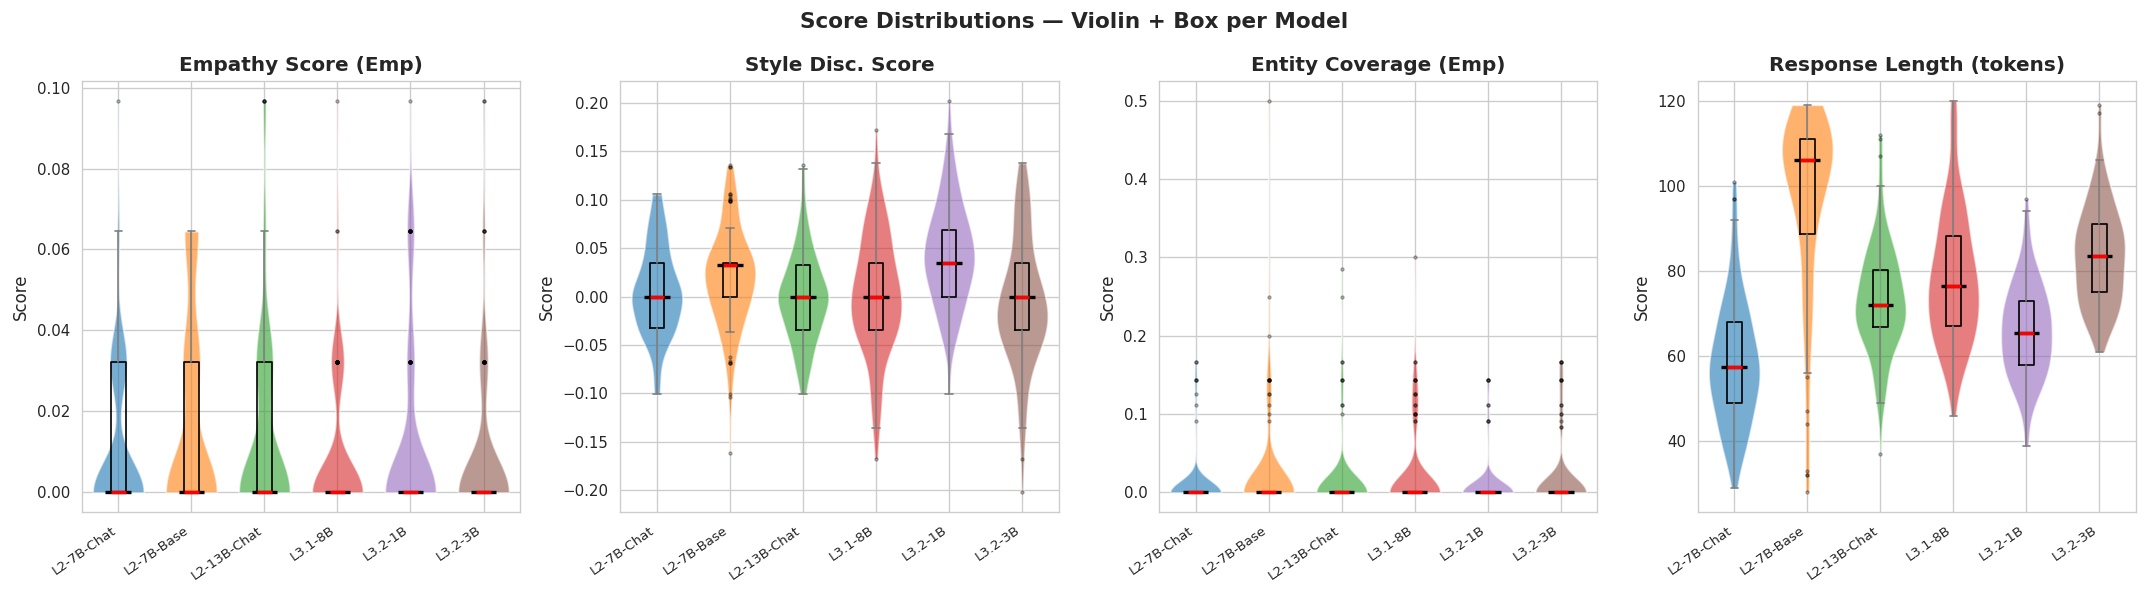

✓ Saved: eval_12_distributions.png


In [23]:
dist_metrics = [
    ('emp_empathy_score',  'Empathy Score (Emp)'),
    ('style_disc_score',   'Style Disc. Score'),
    ('emp_entity_cov',     'Entity Coverage (Emp)'),
    ('emp_token_len',      'Response Length (tokens)'),
]

fig, axes = plt.subplots(1, len(dist_metrics), figsize=(18, 5))
fig.suptitle('Score Distributions — Violin + Box per Model', fontsize=13, fontweight='bold')

for ax, (col, title) in zip(axes, dist_metrics):
    plot_data = []
    plot_labels = []
    for lbl in ORDERED_LABELS:
        df = MODEL_DFS[lbl]
        if col in df.columns:
            plot_data.append(df[col].dropna().values)
            plot_labels.append(SHORT[lbl])

    if not plot_data:
        ax.set_title(f'{title}\n(no data)'); continue

    parts = ax.violinplot(plot_data, positions=range(len(plot_data)),
                          showmedians=True, showextrema=False, widths=0.7)
    for i, (pc, lbl) in enumerate(zip(parts['bodies'], ORDERED_LABELS[:len(plot_data)])):
        pc.set_facecolor(MODEL_COLOR[lbl])
        pc.set_alpha(0.6)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)

    bparts = ax.boxplot(plot_data, positions=range(len(plot_data)),
                        widths=0.2, patch_artist=False,
                        medianprops=dict(color='red', lw=2),
                        whiskerprops=dict(color='gray'),
                        capprops=dict(color='gray'),
                        flierprops=dict(marker='.', color='gray', ms=3, alpha=0.4))

    ax.set_xticks(range(len(plot_labels)))
    ax.set_xticklabels(plot_labels, rotation=35, ha='right', fontsize=8)
    ax.set_title(title)
    ax.set_ylabel('Score')

plt.tight_layout()
plt.savefig('eval_12_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Saved: eval_12_distributions.png')

---
# Part 13 — Composite Score Dashboard

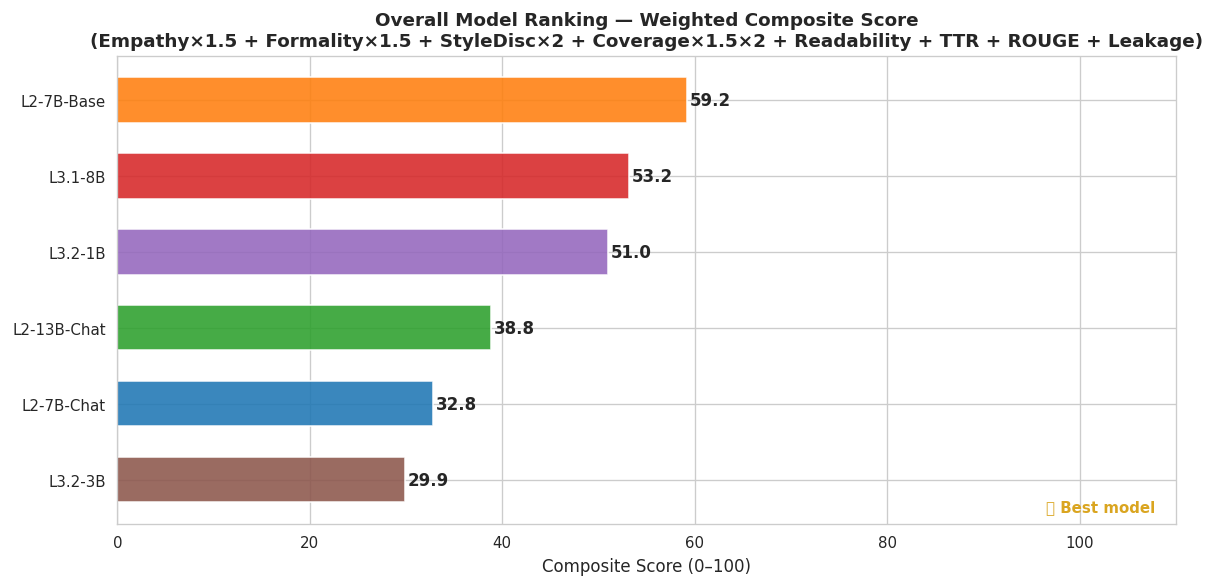

✓ Saved: eval_13_composite_ranking.png

══ FINAL RANKING ══
  #1  L2-7B-Base              Score: 59.21/100
  #2  L3.1-8B                 Score: 53.16/100
  #3  L3.2-1B                 Score: 50.98/100
  #4  L2-13B-Chat             Score: 38.83/100
  #5  L2-7B-Chat              Score: 32.79/100
  #6  L3.2-3B                 Score: 29.88/100


In [24]:
# Compute normalised composite score for each model (all metrics equal weight)
comp_metrics = [
    ('emp_empathy_score',   True, 1.5),   # (col, higher_better, weight)
    ('frm_formality_score', True, 1.5),
    ('style_disc_score',    True, 2.0),
    ('emp_entity_cov',      True, 1.5),
    ('frm_entity_cov',      True, 1.5),
    ('emp_flesch_ease',     True, 1.0),
    ('emp_ttr',             True, 1.0),
    ('rouge1_ef',           False,1.0),
    ('emp_placeholder',     False,1.0),
    ('kg_density',          True, 0.5),
]

# Min-max normalize across models
means = {lbl: {c: MODEL_DFS[lbl][c].mean() if c in MODEL_DFS[lbl].columns else np.nan
               for c,_,_ in comp_metrics}
         for lbl in ORDERED_LABELS}

total_weights = sum(w for _,_,w in comp_metrics)
comp_scores = {}
for lbl in ORDERED_LABELS:
    score = 0.0
    for col, hb, w in comp_metrics:
        all_vals = [means[l][col] for l in ORDERED_LABELS if not np.isnan(means[l].get(col, np.nan))]
        if not all_vals: continue
        mn, mx = min(all_vals), max(all_vals)
        rng = mx - mn if mx != mn else 1
        v = (means[lbl].get(col, mn) - mn) / rng
        if not hb: v = 1 - v
        score += v * w
    comp_scores[lbl] = score / total_weights * 100  # 0–100

# Plot
sorted_labels = sorted(comp_scores, key=comp_scores.get, reverse=True)
fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = [MODEL_COLOR[l] for l in sorted_labels]
vals = [comp_scores[l] for l in sorted_labels]
bars = ax.barh([SHORT[l] for l in sorted_labels], vals,
               color=bar_colors, alpha=0.88, height=0.6)

for bar, v in zip(bars, vals):
    ax.text(v + 0.3, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}', va='center', ha='left', fontsize=10, fontweight='bold')

ax.set_xlabel('Composite Score (0–100)')
ax.set_title('Overall Model Ranking — Weighted Composite Score\n'
             '(Empathy×1.5 + Formality×1.5 + StyleDisc×2 + Coverage×1.5×2 + Readability + TTR + ROUGE + Leakage)',
             fontsize=11, fontweight='bold')
ax.set_xlim(0, 110)
ax.invert_yaxis()

# Annotate 1st place
ax.text(0.98, 0.02, '🏆 Best model', transform=ax.transAxes,
        ha='right', va='bottom', fontsize=9, color='goldenrod', fontweight='bold')

plt.tight_layout()
plt.savefig('eval_13_composite_ranking.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Saved: eval_13_composite_ranking.png')

print('\n══ FINAL RANKING ══')
for rank, lbl in enumerate(sorted_labels, 1):
    print(f'  #{rank}  {SHORT[lbl]:<22}  Score: {comp_scores[lbl]:.2f}/100')

---
# Part 14 — Export Full Results to CSV

In [25]:
# Per-model CSVs
for lbl in ORDERED_LABELS:
    fname = f'metrics_{SHORT[lbl].replace("/","_")}.csv'
    MODEL_DFS[lbl].to_csv(fname, index=False)
    print(f'  ✓ {fname}')

# Combined CSV
ALL_DF.to_csv('metrics_all_models_combined.csv', index=False)
print('  ✓ metrics_all_models_combined.csv')

# Stat test results
stat_all = []
for lbl in ORDERED_LABELS:
    st = all_stat[lbl].copy()
    st.insert(0, 'Model', SHORT[lbl])
    stat_all.append(st)
if stat_all:
    pd.concat(stat_all, ignore_index=True).to_csv('statistical_tests_all_models.csv', index=False)
    print('  ✓ statistical_tests_all_models.csv')

print('\n✓ All outputs saved.')
print()
print('Generated files:')
import os
for f in sorted(os.listdir('.')):
    if f.startswith('eval_') or f in ['leaderboard_summary.csv','metrics_all_models_combined.csv','statistical_tests_all_models.csv']:
        size = os.path.getsize(f)
        print(f'  {f:<55}  {size:>8,} bytes')

  ✓ metrics_L2-7B-Chat.csv
  ✓ metrics_L2-7B-Base.csv
  ✓ metrics_L2-13B-Chat.csv
  ✓ metrics_L3.1-8B.csv
  ✓ metrics_L3.2-1B.csv
  ✓ metrics_L3.2-3B.csv
  ✓ metrics_all_models_combined.csv
  ✓ statistical_tests_all_models.csv

✓ All outputs saved.

Generated files:
  eval_10a_ablation_size.png                                162,151 bytes
  eval_10b_ablation_generation.png                           50,076 bytes
  eval_10c_ablation_type.png                                 48,724 bytes
  eval_10d_ablation_steering.png                             66,245 bytes
  eval_12_distributions.png                                 208,567 bytes
  eval_13_composite_ranking.png                              69,168 bytes
  eval_1_lexical_quality.png                                165,029 bytes
  eval_2_readability.png                                     92,545 bytes
  eval_3_style_fidelity.png                                 175,052 bytes
  eval_4_factual_grounding.png                              102,381

---
## Evaluation Summary

| Section | What it measures |
|---------|------------------|
| **Part 1** Lexical Quality | Response length, vocabulary diversity (TTR), cross-style ROUGE divergence |
| **Part 2** Readability | Flesch Reading Ease, FK Grade, Gunning Fog — how accessible responses are |
| **Part 3** Style Fidelity | How well each model adheres to empathetic vs formal tone |
| **Part 4** Factual Grounding | KG entity coverage rate (overall + per entity type), placeholder leakage |
| **Part 5** KG Structure | Graph quality: node/edge counts, density, average salience |
| **Part 6** Radar Profile | Normalised 6-axis model profiles for at-a-glance comparison |
| **Part 7** Cross-Scenario | Breakdown by scenario, sentiment, urgency |
| **Part 8** Steering Mode | kg_activation vs prompt-steered fallback rates per model |
| **Part 9** Statistical Tests | Welch's t-test + Cohen's d (Bonferroni corrected) per model |
| **Part 10** Ablation Study | Size effect · Generation effect · Base vs Chat/Instruct · Steering rate |
| **Part 11** Leaderboard | Single ranked table with per-metric scores |
| **Part 12** Distributions | Violin + box plots showing score spread per model |
| **Part 13** Composite Ranking | Weighted composite score → final model ranking |
| **Part 14** Export | Full CSVs for all metrics, stat tests, and leaderboard |